# 02 — Análisis Exploratorio de Datos (EDA)

Fase 2: EDA sobre la base de datos seleccionada.

## Exploración inicial de la estructura

Antes de revisar la calidad de los datos, miramos cómo viene la base: cuántos registros y columnas tiene, qué tipo de dato tiene cada columna y qué representa cada variable. En esta primera celda se cargan las librerías y los datos que usa todo el notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ruta_datos = Path("..") / "data" / "raw" / "hcvdat0.csv"
carpeta_imagenes = Path("..") / "images"

df = pd.read_csv(ruta_datos)
print(f"Dimensiones (filas, columnas): {df.shape}")

Dimensiones (filas, columnas): (615, 14)


In [2]:
print("Primeros registros:")
display(df.head())
print("Últimos registros:")
display(df.tail())
print("Muestra aleatoria:")
display(df.sample(5, random_state=42))

Primeros registros:


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


Últimos registros:


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
610,611,3=Cirrhosis,62,f,32.0,416.6,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5
611,612,3=Cirrhosis,64,f,24.0,102.8,2.9,44.4,20.0,1.54,3.02,63.0,35.9,71.3
612,613,3=Cirrhosis,64,f,29.0,87.3,3.5,99.0,48.0,1.66,3.63,66.7,64.2,82.0
613,614,3=Cirrhosis,46,f,33.0,NaN,39.0,62.0,20.0,3.56,4.20,52.0,50.0,71.0
614,615,3=Cirrhosis,59,f,36.0,NaN,100.0,80.0,12.0,9.07,5.30,67.0,34.0,68.0


Muestra aleatoria:


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
248,249,0=Blood Donor,55,m,28.1,65.5,16.6,17.5,2.8,5.58,4.39,65.0,26.2,62.4
365,366,0=Blood Donor,39,f,31.4,106.0,16.6,17.0,2.4,5.95,5.30,68.0,22.9,72.3
432,433,0=Blood Donor,48,f,43.7,50.1,17.3,26.3,8.1,8.15,5.38,64.0,13.4,73.1
610,611,3=Cirrhosis,62,f,32.0,416.6,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5
132,133,0=Blood Donor,44,m,35.5,81.7,27.5,29.5,6.4,8.81,6.65,83.0,24.1,68.0


Con `head()` y `tail()` notamos algo importante: el archivo viene **ordenado por diagnóstico**. Los primeros registros son todos donantes sanos y los últimos son todos pacientes con cirrosis. Por eso también usamos `sample()`, que toma filas al azar (con `random_state=42` para que siempre salgan las mismas) y da una idea más real de cómo se ven los datos mezclados.

También se ve que la primera columna no tiene nombre y pandas la llama `Unnamed: 0`. Sus valores van 1, 2, 3..., así que es solo el número del registro.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    str    
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    str    
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), str(2)
memory usage: 75.7 KB


In [4]:
display(df.describe().T.round(2))
display(df.describe(exclude="number"))

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,615.0,308.00,177.68,1.00,154.50,308.00,461.50,615.00
Age,615.0,47.41,10.06,19.00,39.00,47.00,54.00,77.00
ALB,614.0,41.62,5.78,14.90,38.80,41.95,45.20,82.20
ALP,597.0,68.28,26.03,11.30,52.50,66.20,80.10,416.60
ALT,614.0,28.45,25.47,0.90,16.40,23.00,33.08,325.30
AST,615.0,34.79,33.09,10.60,21.60,25.90,32.90,324.00
BIL,615.0,11.40,19.67,0.80,5.30,7.30,11.20,254.00
CHE,615.0,8.20,2.21,1.42,6.94,8.26,9.59,16.41
CHOL,605.0,5.37,1.13,1.43,4.61,5.30,6.06,9.67
CREA,615.0,81.29,49.76,8.00,67.00,77.00,88.00,1079.10


,Category,Sex
count,615,615
unique,5,2
top,0=Blood Donor,m
freq,533,377


- La base tiene 615 registros y 14 columnas: el identificador, el diagnóstico (`Category`), la edad, el sexo y 10 resultados de laboratorio.
- `info()` muestra que `ALB`, `ALP`, `ALT`, `CHOL` y `PROT` tienen menos de 615 valores no nulos, o sea que tienen faltantes. Eso se analiza en la sección de calidad.
- `Category` y `Sex` son texto, `Unnamed: 0` y `Age` son enteros y los 10 marcadores de laboratorio son decimales (`float64`).
- En `describe()` se ve que los marcadores están en escalas muy distintas: `CHOL` va de 1.43 a 9.67, mientras que `CREA` llega a 1079.1. También hay máximos muy lejos del percentil 75; por ejemplo, en `GGT` el 75 % de los datos está por debajo de 40.2, pero el máximo es 650.9.
- En las categóricas, `Category` tiene 5 valores y el más frecuente es `0=Blood Donor` (533 registros). `Sex` tiene 2 valores y predomina `m` (377 registros).

### Clasificación de las variables

Para clasificar las variables no basta con mirar si pandas las lee como números. Revisamos también cuántos valores distintos tiene cada columna y qué representa.

In [5]:
display(pd.DataFrame({
    "Tipo_de_dato": df.dtypes.astype(str),
    "Valores_distintos": df.nunique(),
}))

,Tipo_de_dato,Valores_distintos
Unnamed: 0,int64,615
Category,str,5
Age,int64,49
Sex,str,2
ALB,float64,189
ALP,float64,414
ALT,float64,341
AST,float64,297
BIL,float64,188
CHE,float64,407


| Variable | Qué representa | Clasificación |
|---|---|---|
| `Unnamed: 0` | Número del registro | Identificador: es numérico, pero no mide nada del paciente, así que no se analiza como variable |
| `Category` | Diagnóstico | Cualitativa nominal |
| `Sex` | Sexo (`m` / `f`) | Cualitativa nominal (binaria) |
| `Age` | Edad en años | Cuantitativa discreta |
| `ALB` | Albúmina | Cuantitativa continua |
| `ALP` | Fosfatasa alcalina | Cuantitativa continua |
| `ALT` | Alanina aminotransferasa | Cuantitativa continua |
| `AST` | Aspartato aminotransferasa | Cuantitativa continua |
| `BIL` | Bilirrubina | Cuantitativa continua |
| `CHE` | Colinesterasa | Cuantitativa continua |
| `CHOL` | Colesterol | Cuantitativa continua |
| `CREA` | Creatinina | Cuantitativa continua |
| `GGT` | Gamma-glutamil transferasa | Cuantitativa continua |
| `PROT` | Proteínas totales | Cuantitativa continua |

Algunas aclaraciones:

- `Unnamed: 0` tiene 615 valores distintos, uno por fila, lo que confirma que es un identificador y no una medición.
- `Age` viene en años enteros (49 edades distintas), por eso la tomamos como discreta.
- Los marcadores de laboratorio son mediciones con decimales y tienen cientos de valores distintos, por eso son continuas.
- En `Category`, los números 1, 2 y 3 siguen la progresión de la enfermedad (hepatitis, fibrosis y cirrosis), pero la categoría `0s` (donante sospechoso) no encaja en ese orden. Por eso la tratamos como nominal y no como ordinal. En este dataset no quedan variables ordinales.

In [6]:
# Grupos de columnas que se usan en el resto del notebook, según la clasificación anterior
columna_id = df.columns[0]
columnas_categoricas = ["Category", "Sex"]
columnas_clinicas = ["ALB", "ALP", "ALT", "AST", "BIL", "CHE", "CHOL", "CREA", "GGT", "PROT"]
columnas_numericas = ["Age"] + columnas_clinicas

## Calidad de los datos: faltantes, duplicados y consistencia

Antes de describir las variables o buscar relaciones entre ellas, revisamos qué tan confiable es la base. Como vimos en las guías de las semanas 1 a 3, la limpieza es una de las primeras etapas del análisis: un dato crudo puede traer valores faltantes, registros repetidos, categorías mal escritas o valores que no tienen sentido, y si no los detectamos a tiempo terminan afectando todo lo que viene después.

En esta sección **solo diagnosticamos** los problemas: los contamos, miramos dónde se concentran y proponemos cómo tratarlos. No imputamos, no eliminamos ni transformamos ningún registro, porque esas decisiones se aplican en el notebook `03_preprocesamiento_reduccion.ipynb`.

In [7]:
# El diagnóstico se hace sobre una copia para preservar los datos cargados.
df_calidad = df.copy()

### Valores faltantes

Primero contamos cuántos valores faltan en cada columna y qué porcentaje representan frente a los 615 registros. Así podemos comparar la magnitud del problema entre variables y no solo mirar el número absoluto.

In [8]:
resumen_faltantes = pd.DataFrame({
    "cantidad_faltante": df_calidad.isna().sum(),
    "porcentaje_faltante": df_calidad.isna().mean().mul(100),
})
resumen_faltantes["porcentaje_faltante"] = (
    resumen_faltantes["porcentaje_faltante"].round(3)
)
resumen_faltantes = resumen_faltantes.sort_values(
    "cantidad_faltante", ascending=False
)
display(resumen_faltantes)

faltantes_totales = int(df_calidad.isna().sum().sum())
filas_con_faltantes = int(df_calidad.isna().any(axis=1).sum())
print(f"Celdas faltantes: {faltantes_totales}")
print(
    f"Filas con al menos un faltante: {filas_con_faltantes} "
    f"({filas_con_faltantes / len(df_calidad) * 100:.3f}%)"
)

,cantidad_faltante,porcentaje_faltante
ALP,18,2.927
CHOL,10,1.626
ALT,1,0.163
PROT,1,0.163
ALB,1,0.163
Category,0,0.000
Age,0,0.000
Sex,0,0.000
Unnamed: 0,0,0.000
AST,0,0.000


Celdas faltantes: 31
Filas con al menos un faltante: 26 (4.228%)


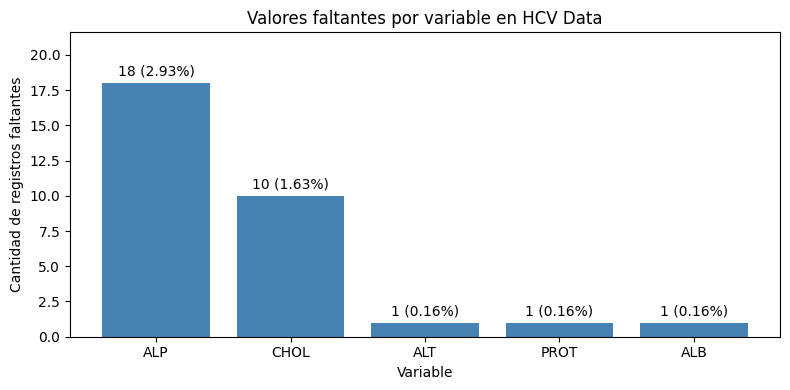

In [9]:
faltantes_grafico = resumen_faltantes.query("cantidad_faltante > 0")

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(
    faltantes_grafico.index,
    faltantes_grafico["cantidad_faltante"],
    color="steelblue",
)
ax.bar_label(
    barras,
    labels=[
        f"{cantidad} ({porcentaje:.2f}%)"
        for cantidad, porcentaje in zip(
            faltantes_grafico["cantidad_faltante"],
            faltantes_grafico["porcentaje_faltante"],
        )
    ],
    padding=3,
)
ax.set_title("Valores faltantes por variable en HCV Data")
ax.set_xlabel("Variable")
ax.set_ylabel("Cantidad de registros faltantes")
ax.set_ylim(0, faltantes_grafico["cantidad_faltante"].max() * 1.2)
plt.tight_layout()
fig.savefig(carpeta_imagenes / "faltantes_por_variable.png", dpi=150)
plt.show()

Con la tabla y la gráfica vemos que el problema de faltantes está concentrado en muy pocas columnas. Solo 5 de las 14 columnas tienen datos ausentes, y todas son pruebas de laboratorio: `ALP` es la más afectada, seguida de `CHOL`, mientras que `ALB`, `ALT` y `PROT` tienen un único faltante cada una. Las variables `Category`, `Age` y `Sex` están completas, lo cual es importante porque son las que usamos para agrupar y comparar pacientes.

Ahora bien, que el porcentaje global sea bajo no quiere decir que el problema sea menor. Hay que mirar **en qué grupos** caen esos faltantes.

In [10]:
columnas_con_faltantes = resumen_faltantes.query(
    "cantidad_faltante > 0"
).index.tolist()
faltantes_por_categoria = (
    df_calidad.groupby("Category", observed=False)[columnas_con_faltantes]
    .agg(lambda serie: serie.isna().sum())
)
display(faltantes_por_categoria)

# Porcentajes dentro de cada categoría: permiten detectar concentración del problema.
porcentaje_faltantes_por_categoria = (
    df_calidad.groupby("Category", observed=False)[columnas_con_faltantes]
    .agg(lambda serie: serie.isna().mean() * 100)
    .round(2)
)
display(porcentaje_faltantes_por_categoria)

,ALP,CHOL,ALT,PROT,ALB
Category,,,,,
0=Blood Donor,0,7,0,0,0
0s=suspect Blood Donor,0,0,0,0,0
1=Hepatitis,3,0,1,0,0
2=Fibrosis,9,1,0,0,0
3=Cirrhosis,6,2,0,1,1


,ALP,CHOL,ALT,PROT,ALB
Category,,,,,
0=Blood Donor,0.00,1.31,0.00,0.00,0.00
0s=suspect Blood Donor,0.00,0.00,0.00,0.00,0.00
1=Hepatitis,12.50,0.00,4.17,0.00,0.00
2=Fibrosis,42.86,4.76,0.00,0.00,0.00
3=Cirrhosis,20.00,6.67,0.00,3.33,3.33


In [11]:
# Registros con más de un faltante: conviene revisarlos uno por uno.
faltantes_por_fila = df_calidad.isna().sum(axis=1)
print("Filas según cantidad de faltantes:")
display(
    faltantes_por_fila[faltantes_por_fila > 0]
    .value_counts()
    .sort_index()
    .rename_axis("faltantes_en_la_fila")
    .to_frame("cantidad_de_filas")
)

filas_varios_faltantes = df_calidad.loc[faltantes_por_fila > 1]
display(filas_varios_faltantes)
for indice, fila in filas_varios_faltantes.iterrows():
    columnas_ausentes = fila[fila.isna()].index.tolist()
    print(f"{columna_id} = {fila[columna_id]} ({fila['Category']}): falta {columnas_ausentes}")

Filas según cantidad de faltantes:


,cantidad_de_filas
faltantes_en_la_fila,
1,23
2,1
3,2


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
584,585,2=Fibrosis,75,f,36.0,NaN,114.0,125.0,14.0,6.65,NaN,57.0,177.0,72.0
590,591,3=Cirrhosis,46,m,20.0,NaN,62.0,113.0,254.0,1.48,NaN,114.0,138.0,NaN
603,604,3=Cirrhosis,65,m,NaN,NaN,40.0,54.0,13.0,7.50,NaN,70.0,107.0,79.0


Unnamed: 0 = 585 (2=Fibrosis): falta ['ALP', 'CHOL']
Unnamed: 0 = 591 (3=Cirrhosis): falta ['ALP', 'CHOL', 'PROT']
Unnamed: 0 = 604 (3=Cirrhosis): falta ['ALB', 'ALP', 'CHOL']


#### Interpretación e impacto de los faltantes

Al separar por diagnóstico aparece el hallazgo más importante de esta sección: **los faltantes de `ALP` no están repartidos al azar**. Ningún donante (sano o sospechoso) tiene `ALP` vacío; los 18 casos están en los grupos clínicos: 3 en Hepatitis (12.5% del grupo), 9 en Fibrosis (42.86%) y 6 en Cirrosis (20%). O sea, casi la mitad de los pacientes con fibrosis no tiene esa prueba registrada.

Esto pesa mucho porque los grupos clínicos son pequeños (24, 21 y 30 registros frente a 533 donantes). Si simplemente borráramos las filas incompletas, perderíamos una parte grande justo de los pacientes que más nos interesan y el desbalance entre clases sería todavía peor.

| Variable | Faltantes | % global | Dónde se concentran | Impacto | Estrategia propuesta (se aplica en el notebook 03) |
|---|---:|---:|---|---|---|
| `ALP` | 18 | 2.93% | Hepatitis (3), Fibrosis (9), Cirrosis (6) | Alto: afecta solo a grupos clínicos pequeños | No eliminar filas. Imputar con la **mediana** del grupo diagnóstico y evaluar crear un **indicador** de faltante, ya que la ausencia misma parece estar relacionada con el diagnóstico |
| `CHOL` | 10 | 1.63% | Donantes (7), Fibrosis (1), Cirrosis (2) | Medio: bajo en donantes, pero afecta a grupos clínicos | Imputar con la **mediana** del grupo diagnóstico |
| `ALB` | 1 | 0.16% | Cirrosis (1) | Bajo | Imputar con la mediana del grupo; el registro también tiene vacíos `ALP` y `CHOL`, por eso se revisa junto con ellos |
| `ALT` | 1 | 0.16% | Hepatitis (1) | Bajo | Imputar con la mediana del grupo |
| `PROT` | 1 | 0.16% | Cirrosis (1) | Bajo | Imputar con la mediana del grupo; el registro también tiene vacíos `ALP` y `CHOL` |

En total hay **31 celdas vacías repartidas en 26 filas (4.23% de los registros)**: 23 filas tienen un solo faltante, 1 fila tiene dos y 2 filas tienen tres. Esas dos filas con tres faltantes son pacientes con cirrosis, y ojo que `ALB` y `PROT` **no** están en el mismo registro: a uno le falta `ALB`, `ALP` y `CHOL`, y al otro `ALP`, `CHOL` y `PROT`.

Proponemos la **mediana** y no la media porque, como vimos en la semana 4, la media es sensible a valores extremos, y en estas pruebas de laboratorio hay máximos muy altos. Además, calcularla por grupo diagnóstico evita rellenar a un paciente con cirrosis usando valores típicos de donantes sanos.

### Registros duplicados

Buscamos duplicados de dos formas: comparando todas las columnas y comparando todas **menos** la primera, que funciona como identificador. La segunda revisión es la importante, porque dos filas con los mismos valores clínicos pero con número de registro distinto no aparecerían como duplicadas en la primera.

In [12]:
duplicados_exactos = df_calidad.duplicated(keep=False)
columnas_sin_id = df_calidad.columns.drop(columna_id)
duplicados_sin_id = df_calidad.duplicated(
    subset=columnas_sin_id, keep=False
)
print(f"Filas involucradas en duplicados exactos: {duplicados_exactos.sum()}")
print(
    "Filas involucradas en duplicados al ignorar el identificador: "
    f"{duplicados_sin_id.sum()}"
)
if duplicados_sin_id.any():
    display(df_calidad.loc[duplicados_sin_id].sort_values(list(columnas_sin_id)))

Filas involucradas en duplicados exactos: 0
Filas involucradas en duplicados al ignorar el identificador: 0


**Interpretación:** no encontramos registros duplicados en ninguna de las dos revisiones, así que no hay que eliminar filas por este motivo. Esta verificación hay que repetirla en el notebook 03 después de cualquier transformación, por si algún paso de limpieza llega a generar filas repetidas.

### Valores inconsistentes y posibles errores de formato

Revisamos que las variables categóricas solo tengan los valores esperados (sin espacios de más ni variantes en mayúsculas/minúsculas), que el identificador no se repita ni tenga vacíos y que las columnas que deberían ser numéricas no tengan texto escondido.

In [13]:
categorias_esperadas = {
    "0=Blood Donor",
    "0s=suspect Blood Donor",
    "1=Hepatitis",
    "2=Fibrosis",
    "3=Cirrhosis",
}
sexos_esperados = {"m", "f"}
categorias_observadas = set(df_calidad["Category"].dropna().unique())
sexos_observados = set(df_calidad["Sex"].dropna().unique())

resumen_consistencia = pd.Series({
    "categorias_no_reconocidas": len(categorias_observadas - categorias_esperadas),
    "sexos_no_reconocidos": len(sexos_observados - sexos_esperados),
    "identificadores_duplicados": int(df_calidad[columna_id].duplicated().sum()),
    "identificadores_faltantes": int(df_calidad[columna_id].isna().sum()),
    "identificador_secuencial_1_a_n": bool(
        df_calidad[columna_id].reset_index(drop=True).eq(
            pd.Series(range(1, len(df_calidad) + 1))
        ).all()
    ),
})
display(resumen_consistencia.to_frame("resultado"))

for columna in ["Category", "Sex"]:
    print(f"Valores y frecuencias de {columna}:")
    display(df_calidad[columna].value_counts(dropna=False).to_frame("frecuencia"))

,resultado
categorias_no_reconocidas,0
sexos_no_reconocidos,0
identificadores_duplicados,0
identificadores_faltantes,0
identificador_secuencial_1_a_n,True


Valores y frecuencias de Category:


,frecuencia
Category,
0=Blood Donor,533
3=Cirrhosis,30
1=Hepatitis,24
2=Fibrosis,21
0s=suspect Blood Donor,7


Valores y frecuencias de Sex:


,frecuencia
Sex,
m,377
f,238


In [14]:
columnas_numericas_esperadas = [
    columna for columna in df_calidad.columns
    if columna not in columnas_categoricas
]
filas_con_espacios = pd.Series(False, index=df_calidad.index)
for columna in columnas_categoricas:
    serie_texto = df_calidad[columna].astype("string")
    filas_con_espacios |= serie_texto.ne(serie_texto.str.strip()).fillna(False)

conversion_numerica = df_calidad[columnas_numericas_esperadas].apply(
    pd.to_numeric, errors="coerce"
)
errores_conversion = (
    conversion_numerica.isna() & df_calidad[columnas_numericas_esperadas].notna()
).sum()
valores_infinitos = np.isinf(conversion_numerica).sum()
display(pd.DataFrame({
    "errores_conversion_numerica": errores_conversion,
    "valores_infinitos": valores_infinitos,
}))
print(f"Filas con espacios al inicio o al final: {filas_con_espacios.sum()}")

,errores_conversion_numerica,valores_infinitos
Unnamed: 0,0,0
Age,0,0
ALB,0,0
ALP,0,0
ALT,0,0
AST,0,0
BIL,0,0
CHE,0,0
CHOL,0,0
CREA,0,0


Filas con espacios al inicio o al final: 0


**Interpretación:** `Category` solo tiene las cinco etiquetas documentadas y `Sex` solo `m` y `f`, sin espacios ni variantes. Las columnas numéricas no tienen texto inesperado ni valores infinitos, y el identificador va de 1 a 615 sin repetirse. En ese sentido, la base está bien construida.

Aun así encontramos tres detalles de formato que hay que tener en cuenta para el preprocesamiento:

1. **Columna sin nombre.** La primera columna llega del CSV sin encabezado y pandas la nombra `Unnamed: 0`. Por sus valores es solo un número de registro, no una medición clínica, así que en el notebook 03 hay que renombrarla o quitarla antes de escalar o aplicar PCA; si se deja, el modelo la tomaría como si fuera información del paciente.
2. **Etiquetas de `Category` que mezclan código y texto.** Valores como `0=Blood Donor` o `3=Cirrhosis` traen el número y el nombre en el mismo texto. Sirven para leer, pero para codificar habrá que separarlos o mapearlos de forma explícita.
3. **La categoría `0s=suspect Blood Donor`.** Son solo 7 registros de donantes "sospechosos", que no encajan del todo ni como sanos ni como enfermos. No es un error de digitación, pero sí una categoría ambigua; queda pendiente decidir si se conserva aparte o se agrupa con otra clase, y esa decisión debe justificarse con los análisis siguientes.

### Rangos aparentemente inválidos

Acá no usamos rangos clínicos de referencia, porque no somos médicos y un valor muy alto puede ser perfectamente normal en un paciente enfermo. Aplicamos reglas mínimas de validez: la edad debe estar entre 0 y 120 años y las mediciones de laboratorio deben ser mayores que cero (no existe una concentración negativa).

In [15]:
rangos_observados = df_calidad[["Age"] + columnas_clinicas].agg(
    ["min", "max"]
).T
rangos_observados["valores_no_positivos"] = (
    df_calidad[["Age"] + columnas_clinicas] <= 0
).sum()
display(rangos_observados)

edad_invalida = ~df_calidad["Age"].between(0, 120, inclusive="both")
clinicos_invalidos = (df_calidad[columnas_clinicas] <= 0).sum()
print(f"Edades fuera de 0–120 años: {edad_invalida.sum()}")
print(f"Mediciones clínicas no positivas: {clinicos_invalidos.sum()}")

,min,max,valores_no_positivos
Age,19.00,77.00,0
ALB,14.90,82.20,0
ALP,11.30,416.60,0
ALT,0.90,325.30,0
AST,10.60,324.00,0
BIL,0.80,254.00,0
CHE,1.42,16.41,0
CHOL,1.43,9.67,0
CREA,8.00,1079.10,0
GGT,4.50,650.90,0


Edades fuera de 0–120 años: 0
Mediciones clínicas no positivas: 0


**Interpretación:** no hay edades imposibles ni valores negativos o en cero en las pruebas de laboratorio. Las edades van de 19 a 77 años, lo cual es razonable. Sí llaman la atención algunos máximos muy altos, por ejemplo `CREA` (1079.1), `GGT` (650.9), `ALT`, `AST` y `BIL`, pero pueden corresponder a pacientes con enfermedad hepática, así que por ahora **no los consideramos errores**. Su revisión como posibles valores atípicos (boxplots, IQR) corresponde a la sección de distribuciones y outliers.

### Conclusión del diagnóstico de calidad

En general, HCV Data es una base limpia en estructura: no tiene duplicados, las categorías están bien escritas, los tipos de datos son correctos y no hay rangos imposibles. El problema principal son los **valores faltantes**, que aunque son pocos (4.23% de las filas) se concentran en los grupos clínicos, sobre todo `ALP` en Fibrosis.

Resumen de lo que queda para el preprocesamiento (notebook 03):

| Problema detectado | Propuesta |
|---|---|
| 18 faltantes de `ALP` concentrados en grupos clínicos | No eliminar filas; imputar con la mediana por diagnóstico y evaluar un indicador de faltante |
| Faltantes aislados en `CHOL`, `ALB`, `ALT` y `PROT` | Imputar con la mediana por diagnóstico |
| Columna identificadora sin nombre (`Unnamed: 0`) | Renombrarla o excluirla antes de escalar y aplicar PCA |
| Etiquetas de `Category` con código y texto juntos | Separarlos o mapearlos antes de codificar |
| Categoría ambigua `0s=suspect Blood Donor` (7 registros) | Decidir con justificación si se conserva o se agrupa |

Ninguna de estas correcciones se aplica todavía: dejamos los datos originales intactos para que el diagnóstico quede separado de la limpieza definitiva.

## Estadística descriptiva y análisis univariado

En esta parte resumimos cada variable por separado para entender sus valores típicos, qué tanto cambian y cómo se distribuyen. El identificador se deja por fuera porque solo identifica el registro y no representa una característica del paciente. Para las categorías miramos tanto las frecuencias como los porcentajes.

### Variables numéricas

In [16]:
# Medidas de tendencia central, dispersión y forma de cada variable numérica
numericas = df[columnas_numericas]
estadisticas = pd.DataFrame({
    "Media": numericas.mean(),
    "Mediana": numericas.median(),
    "Moda": numericas.apply(lambda serie: ", ".join(f"{valor:g}" for valor in serie.mode())),
    "Varianza": numericas.var(),
    "Desviacion_estandar": numericas.std(),
    "Rango": numericas.max() - numericas.min(),
    "IQR": numericas.quantile(0.75) - numericas.quantile(0.25),
    "Asimetria": numericas.skew(),
    "Curtosis": numericas.kurt(),
})
display(estadisticas.round(3))

,Media,Mediana,Moda,Varianza,Desviacion_estandar,Rango,IQR,Asimetria,Curtosis
Age,47.408,47.00,46,101.105,10.055,58.00,15.000,0.267,-0.386
ALB,41.620,41.95,39,33.416,5.781,67.30,6.400,-0.177,5.983
ALP,68.284,66.20,"52.5, 61.2",677.473,26.028,405.30,27.600,4.655,54.973
ALT,28.451,23.00,16.6,648.705,25.470,324.40,16.675,5.506,47.129
AST,34.786,25.90,"22, 23.9, 24.3",1094.994,33.091,313.40,11.300,4.940,30.837
BIL,11.397,7.30,6,387.033,19.673,253.20,5.900,8.385,83.187
CHE,8.197,8.26,7.52,4.865,2.206,14.99,2.655,-0.110,1.315
CHOL,5.368,5.30,"5.07, 5.1",1.283,1.133,8.24,1.450,0.376,0.694
CREA,81.288,77.00,74,2475.676,49.756,1071.10,21.000,15.169,280.100
GGT,39.533,23.30,"13, 14.5, 19.1, 24.1",2987.833,54.661,646.40,24.500,5.633,43.713


- **Tendencia central:** en `Age`, `ALB`, `CHE`, `CHOL` y `PROT` la media y la mediana casi coinciden (por ejemplo, en `Age` son 47.41 y 47). En `ALT`, `AST`, `BIL` y `GGT` la media queda bastante por encima de la mediana (en `GGT`, 39.53 contra 23.3), señal de que unos pocos valores muy altos la jalan hacia arriba.
- **Moda:** en varias variables salen varias modas (`ALP`, `AST`, `CHOL`, `GGT`). Como son variables continuas con cientos de valores distintos, casi ningún valor se repite mucho y la moda no dice gran cosa. Como vimos en la guía de la semana 4, la moda es más útil en variables nominales.
- **Dispersión:** las varianzas son muy distintas entre variables: `GGT` (2987.83) y `CREA` (2475.68) contra `CHE` (4.87) y `CHOL` (1.28). Esto se debe a las unidades de cada marcador, y por eso en el notebook 03 hay que estandarizar antes del PCA.
- **Rango contra IQR:** el rango se infla con los valores extremos. En `CREA` el rango es 1071.1, pero el 50 % central de los datos cabe en un IQR de solo 21. En variables así, el IQR describe mejor la dispersión típica.
- **Forma:** seis marcadores (`ALP`, `ALT`, `AST`, `BIL`, `CREA` y `GGT`) tienen asimetría mayor a 4 y curtosis alta, y `PROT` tiene sesgo negativo moderado (-0.96). Esto se analiza en detalle en la sección de distribuciones y valores atípicos.

### Variables categóricas

In [17]:
for columna in columnas_categoricas:
    frecuencias = df[columna].value_counts(dropna=False).to_frame("Frecuencia")
    frecuencias["Porcentaje"] = (df[columna].value_counts(dropna=False, normalize=True) * 100).round(2)
    display(frecuencias)

,Frecuencia,Porcentaje
Category,,
0=Blood Donor,533,86.67
3=Cirrhosis,30,4.88
1=Hepatitis,24,3.90
2=Fibrosis,21,3.41
0s=suspect Blood Donor,7,1.14


,Frecuencia,Porcentaje
Sex,,
m,377,61.3
f,238,38.7


- `Category` está muy desbalanceada: el 86.67 % son donantes sanos (533 registros) y las otras cuatro categorías juntas apenas suman el 13.33 %. La más pequeña es `0s=suspect Blood Donor`, con 7 registros (1.14 %). Hay que tenerlo en cuenta al comparar grupos, porque con tan pocos pacientes por categoría las medidas de esos grupos son menos estables.
- En `Sex` hay más hombres (61.3 %) que mujeres (38.7 %).

### Gráficas

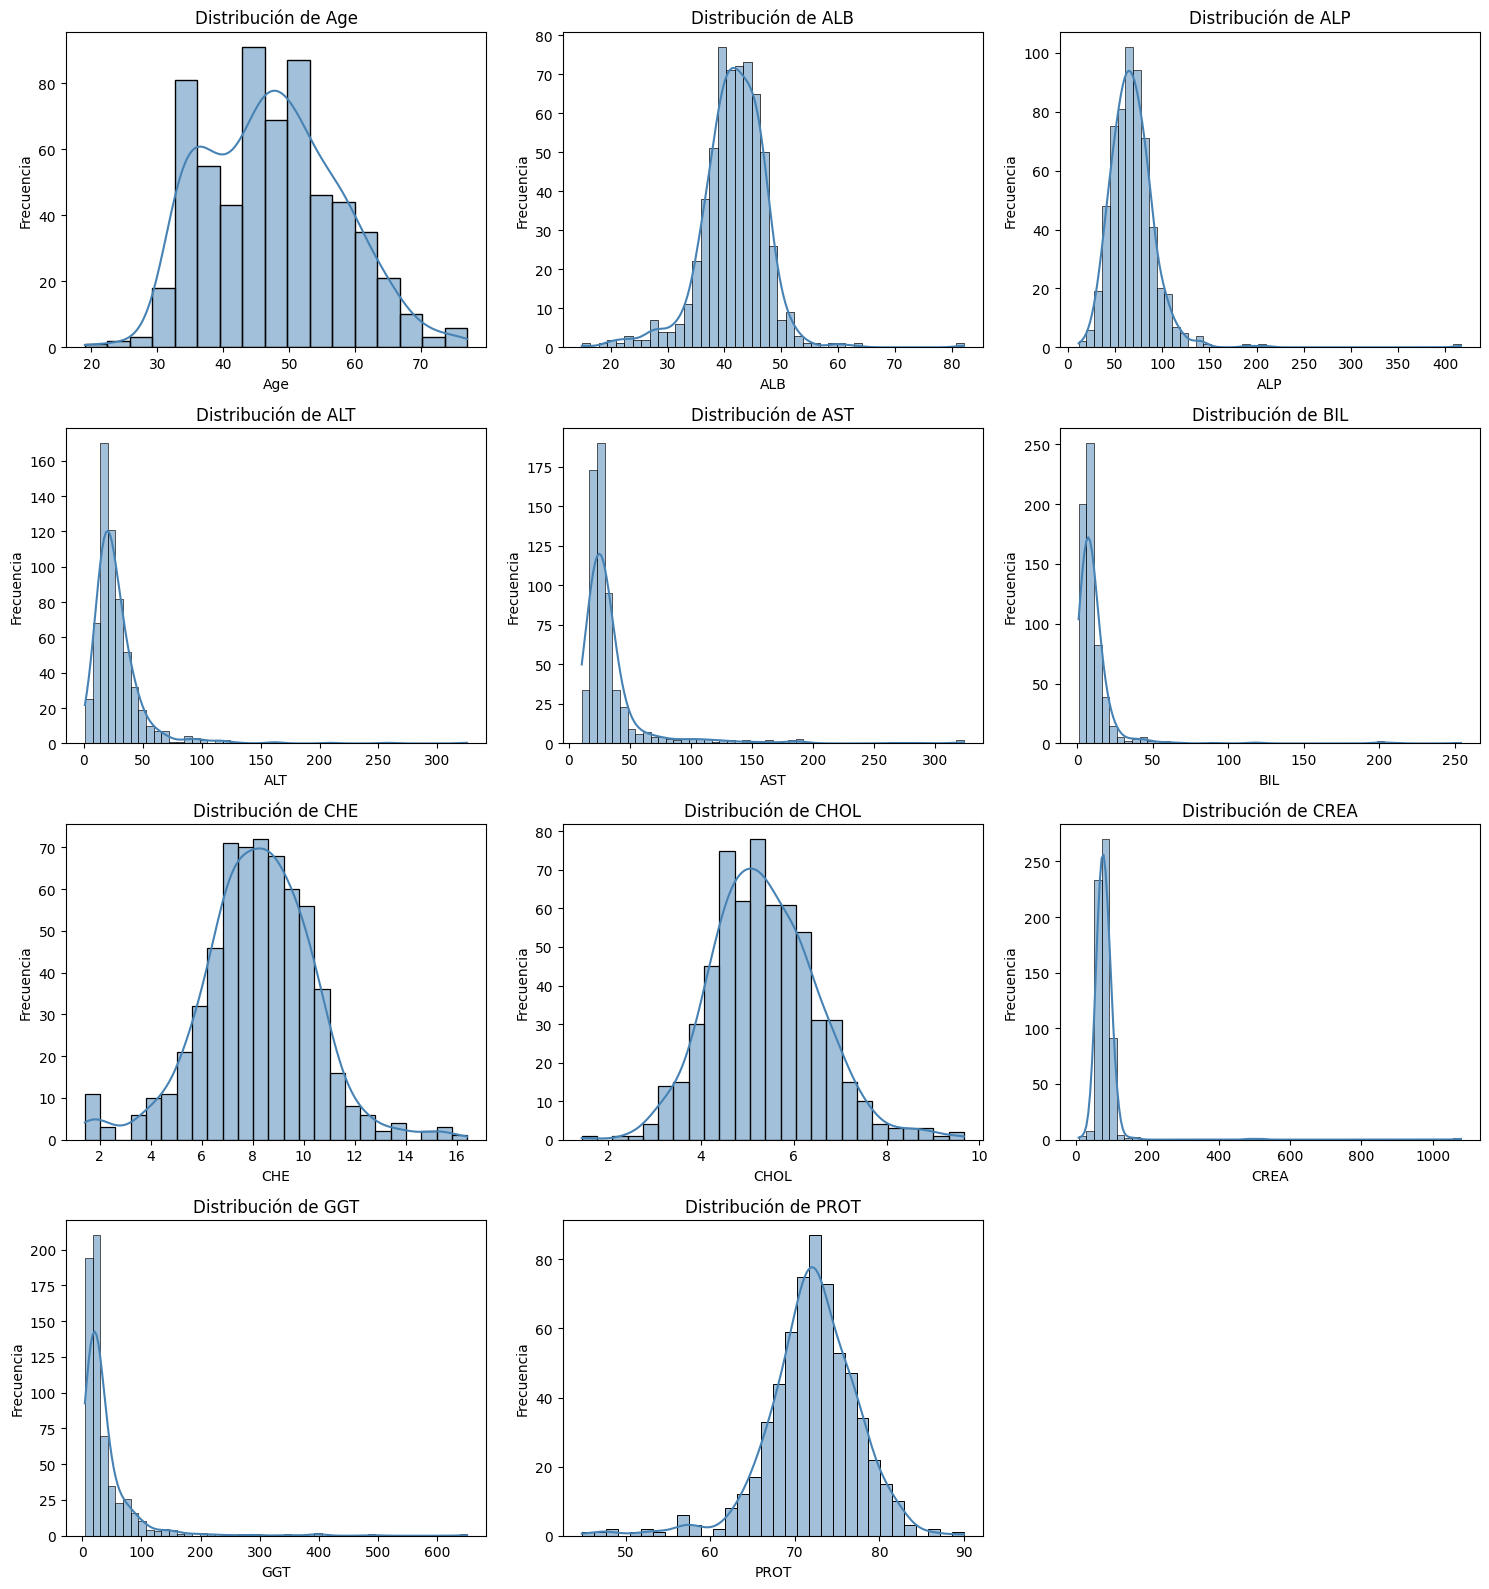

In [18]:
# Histogramas con densidad para revisar la forma y dispersión de cada variable
filas_grafico = int(np.ceil(len(columnas_numericas) / 3))
fig, ejes = plt.subplots(filas_grafico, 3, figsize=(15, 4 * filas_grafico), squeeze=False)
for eje, columna in zip(ejes.flat, columnas_numericas):
    sns.histplot(data=df, x=columna, kde=True, ax=eje, color="steelblue")
    eje.set_title(f"Distribución de {columna}")
    eje.set_xlabel(columna)
    eje.set_ylabel("Frecuencia")
for eje in ejes.flat[len(columnas_numericas):]:
    eje.set_visible(False)
fig.tight_layout()
plt.show()

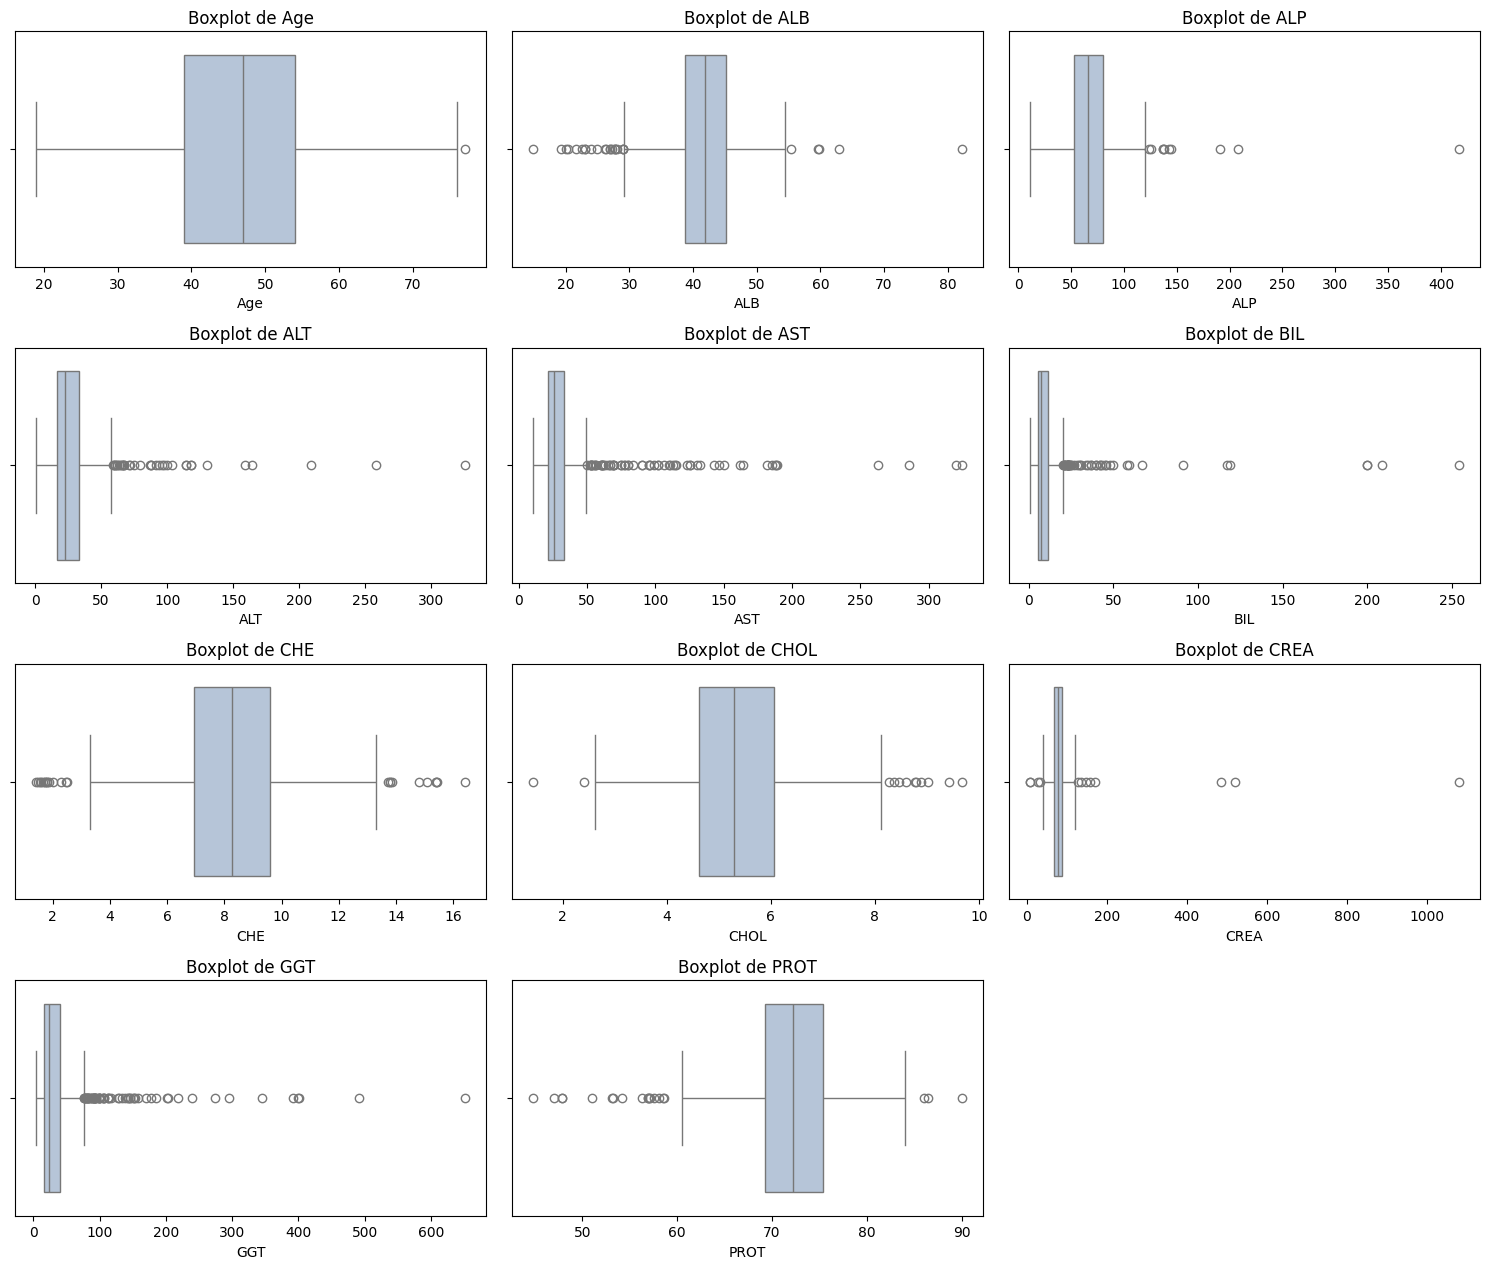

In [19]:
# Los boxplots facilitan comparar medianas, rangos y posibles valores extremos
fig, ejes = plt.subplots(filas_grafico, 3, figsize=(15, 3.2 * filas_grafico), squeeze=False)
for eje, columna in zip(ejes.flat, columnas_numericas):
    sns.boxplot(data=df, x=columna, ax=eje, color="lightsteelblue")
    eje.set_title(f"Boxplot de {columna}")
    eje.set_xlabel(columna)
for eje in ejes.flat[len(columnas_numericas):]:
    eje.set_visible(False)
fig.tight_layout()
plt.show()

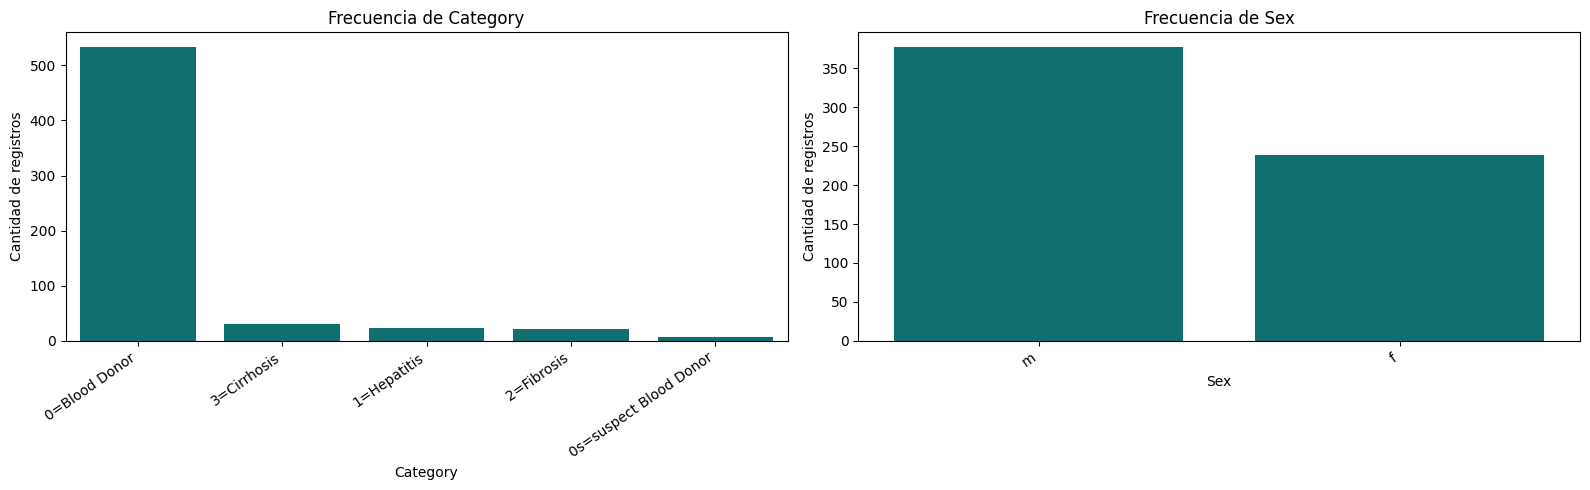

In [20]:
# Barras con las categorías y sus cantidades, sin cambiar las etiquetas originales
fig, ejes = plt.subplots(1, len(columnas_categoricas), figsize=(8 * len(columnas_categoricas), 5), squeeze=False)
for eje, columna in zip(ejes.flat, columnas_categoricas):
    orden = df[columna].value_counts().index
    sns.countplot(data=df, x=columna, order=orden, ax=eje, color="teal")
    eje.set_title(f"Frecuencia de {columna}")
    eje.set_xlabel(columna)
    eje.set_ylabel("Cantidad de registros")
    eje.tick_params(axis="x", rotation=35)
    for etiqueta in eje.get_xticklabels():
        etiqueta.set_ha("right")
fig.tight_layout()
plt.show()

- En los histogramas, `Age`, `ALB`, `CHE`, `CHOL` y `PROT` tienen forma de campana, mientras que `ALT`, `AST`, `BIL`, `CREA` y `GGT` tienen casi todos los datos pegados a la izquierda y una cola larga hacia la derecha. `ALP` también tiene cola, pero menos marcada.
- Los boxplots muestran muchos puntos por fuera de los bigotes en esas mismas variables, sobre todo en `AST`, `GGT` y `BIL`. En la sección de distribuciones y valores atípicos se revisa a quién pertenecen y si son errores.
- La gráfica de barras de `Category` deja ver a simple vista el desbalance entre donantes y pacientes.

## Distribuciones y valores atípicos

En la sección anterior ya se calcularon la asimetría y la curtosis de cada variable y se graficaron sus histogramas y boxplots. Aquí vamos un paso más allá:

1. Clasificamos la forma de cada distribución (simétrica, sesgo positivo o sesgo negativo) y revisamos si alguna necesitaría una transformación.
2. Detectamos valores atípicos con el método IQR y con el z-score.
3. Revisamos a qué pacientes pertenecen esos atípicos para decidir, variable por variable, si parecen errores o valores reales. Aquí también respondemos lo que quedó pendiente en la revisión de rangos sobre los máximos tan altos de `CREA`, `GGT`, `ALT`, `AST` y `BIL`.

Igual que en la sección de calidad, aquí **solo analizamos**: no se elimina ni se transforma ningún dato, las decisiones se aplican en el notebook 03.

### Forma de las distribuciones

Tomamos la asimetría y la curtosis que ya están en la tabla `estadisticas` y clasificamos cada variable con esta regla:

- entre -0.5 y 0.5: aproximadamente simétrica;
- entre 0.5 y 1 (o entre -1 y -0.5): sesgo moderado;
- mayor a 1 (o menor a -1): sesgo fuerte.

Si la asimetría es positiva, la cola larga está a la derecha (unos pocos valores muy altos), y si es negativa, está a la izquierda. También comparamos la media con la mediana: como vimos en la guía de la semana 4, la media se deja jalar por los valores extremos y la mediana no, así que si la media queda muy por encima de la mediana es otra señal de sesgo positivo.

In [21]:
def clasificar_asimetria(asimetria):
    if abs(asimetria) < 0.5:
        return "Aproximadamente simétrica"
    direccion = "positivo" if asimetria > 0 else "negativo"
    intensidad = "moderado" if abs(asimetria) <= 1 else "fuerte"
    return f"Sesgo {direccion} {intensidad}"


forma = estadisticas.loc[columnas_numericas, ["Media", "Mediana", "Asimetria", "Curtosis"]].copy()
forma["Media_menos_mediana"] = forma["Media"] - forma["Mediana"]
forma["Forma"] = forma["Asimetria"].apply(clasificar_asimetria)
forma = forma.sort_values("Asimetria", ascending=False)
display(forma.round(2))

,Media,Mediana,Asimetria,Curtosis,Media_menos_mediana,Forma
CREA,81.29,77.00,15.17,280.10,4.29,Sesgo positivo fuerte
BIL,11.40,7.30,8.39,83.19,4.10,Sesgo positivo fuerte
GGT,39.53,23.30,5.63,43.71,16.23,Sesgo positivo fuerte
ALT,28.45,23.00,5.51,47.13,5.45,Sesgo positivo fuerte
AST,34.79,25.90,4.94,30.84,8.89,Sesgo positivo fuerte
ALP,68.28,66.20,4.65,54.97,2.08,Sesgo positivo fuerte
CHOL,5.37,5.30,0.38,0.69,0.07,Aproximadamente simétrica
Age,47.41,47.00,0.27,-0.39,0.41,Aproximadamente simétrica
CHE,8.20,8.26,-0.11,1.31,-0.06,Aproximadamente simétrica
ALB,41.62,41.95,-0.18,5.98,-0.33,Aproximadamente simétrica


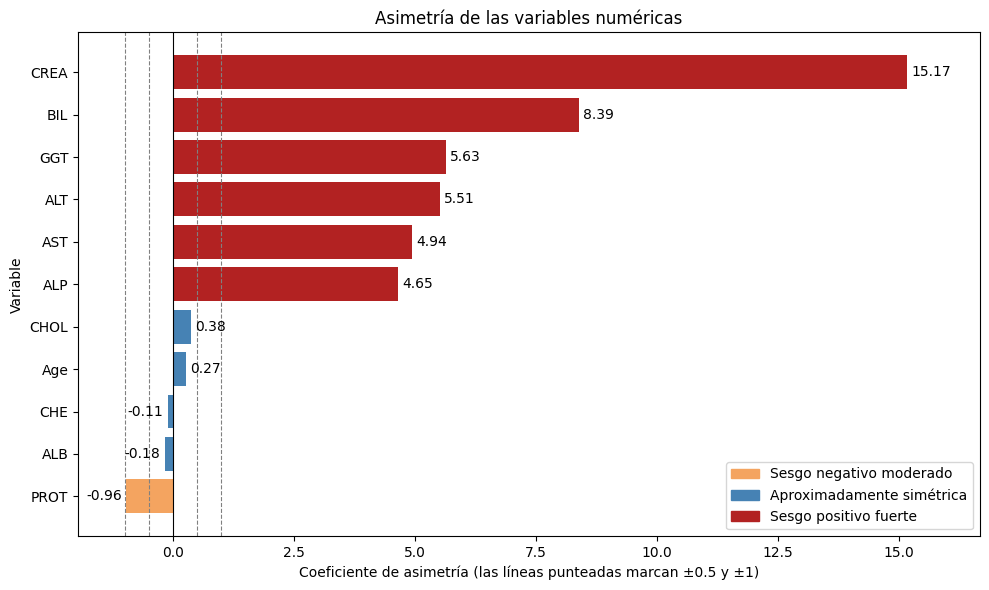

In [22]:
colores_forma = {
    "Aproximadamente simétrica": "steelblue",
    "Sesgo positivo moderado": "sandybrown",
    "Sesgo negativo moderado": "sandybrown",
    "Sesgo positivo fuerte": "firebrick",
    "Sesgo negativo fuerte": "firebrick",
}
forma_grafico = forma.sort_values("Asimetria")

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.barh(
    forma_grafico.index,
    forma_grafico["Asimetria"],
    color=forma_grafico["Forma"].map(colores_forma),
)
ax.bar_label(barras, fmt="%.2f", padding=3)
for limite in [-1, -0.5, 0.5, 1]:
    ax.axvline(limite, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

# Leyenda solo con las formas que aparecen en los datos
formas_presentes = forma_grafico["Forma"].unique()
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=colores_forma[f]) for f in formas_presentes],
    labels=list(formas_presentes),
    loc="lower right",
)
ax.set_title("Asimetría de las variables numéricas")
ax.set_xlabel("Coeficiente de asimetría (las líneas punteadas marcan ±0.5 y ±1)")
ax.set_ylabel("Variable")
ax.set_xlim(forma_grafico["Asimetria"].min() - 1, forma_grafico["Asimetria"].max() + 1.5)
plt.tight_layout()
plt.show()

**Lo que muestran la tabla, el gráfico y los histogramas de la sección anterior:**

- **Aproximadamente simétricas:** `Age`, `ALB`, `CHE` y `CHOL`. En estas la media y la mediana casi coinciden. Ojo que `Age` no tiene una campana perfecta: en su histograma se ven dos picos, uno cerca de los 35 años y otro entre 45 y 50. Y en `CHE` aparece un grupito aparte en valores muy bajos (entre 1.4 y 2.5) que revisamos más abajo.
- **Sesgo negativo moderado:** `PROT` (-0.96). Tiene una cola hacia valores bajos.
- **Sesgo positivo fuerte:** `CREA`, `BIL`, `GGT`, `ALT`, `AST` y `ALP`, todas con asimetría mayor a 4. La mayoría de pacientes tiene valores bajos y unos pocos tienen valores muy altos. Por eso la media queda por encima de la mediana: en `GGT` la diferencia es de 16.23 y en `AST` de 8.89.
- **Curtosis:** las seis variables con sesgo fuerte tienen curtosis muy alta (`CREA` llega a 280.1), lo que confirma colas pesadas. `ALB` es simétrica pero tiene curtosis de 5.98, o sea que tiene valores extremos hacia los dos lados.

Ninguna variable numérica se parece del todo a una distribución normal: incluso las simétricas tienen colas más pesadas o, como `Age`, dos picos. Esto hay que tenerlo en cuenta para las hipótesis, porque la prueba t de Student supone que los datos son aproximadamente normales (guía de la semana 6). Además, las variables con sesgo fuerte podrían necesitar una transformación antes del escalado y del PCA.

### ¿Sirve una transformación logarítmica?

El enunciado menciona la transformación logarítmica para las variables sesgadas. Probamos `np.log1p` (logaritmo de 1 + x, que funciona aunque haya valores muy cercanos a cero) para ver cómo cambia la asimetría. Esto es solo una prueba: no modifica los datos.

In [23]:
asimetria_log = pd.DataFrame({
    "Asimetria_original": df[columnas_numericas].skew(),
    "Asimetria_con_log": np.log1p(df[columnas_numericas]).skew(),
}).round(2)
display(asimetria_log.sort_values("Asimetria_original", ascending=False))

,Asimetria_original,Asimetria_con_log
CREA,15.17,0.87
BIL,8.39,1.48
GGT,5.63,1.03
ALT,5.51,-0.08
AST,4.94,1.96
ALP,4.65,-0.18
CHOL,0.38,-0.36
Age,0.27,-0.23
CHE,-0.11,-1.65
ALB,-0.18,-1.64


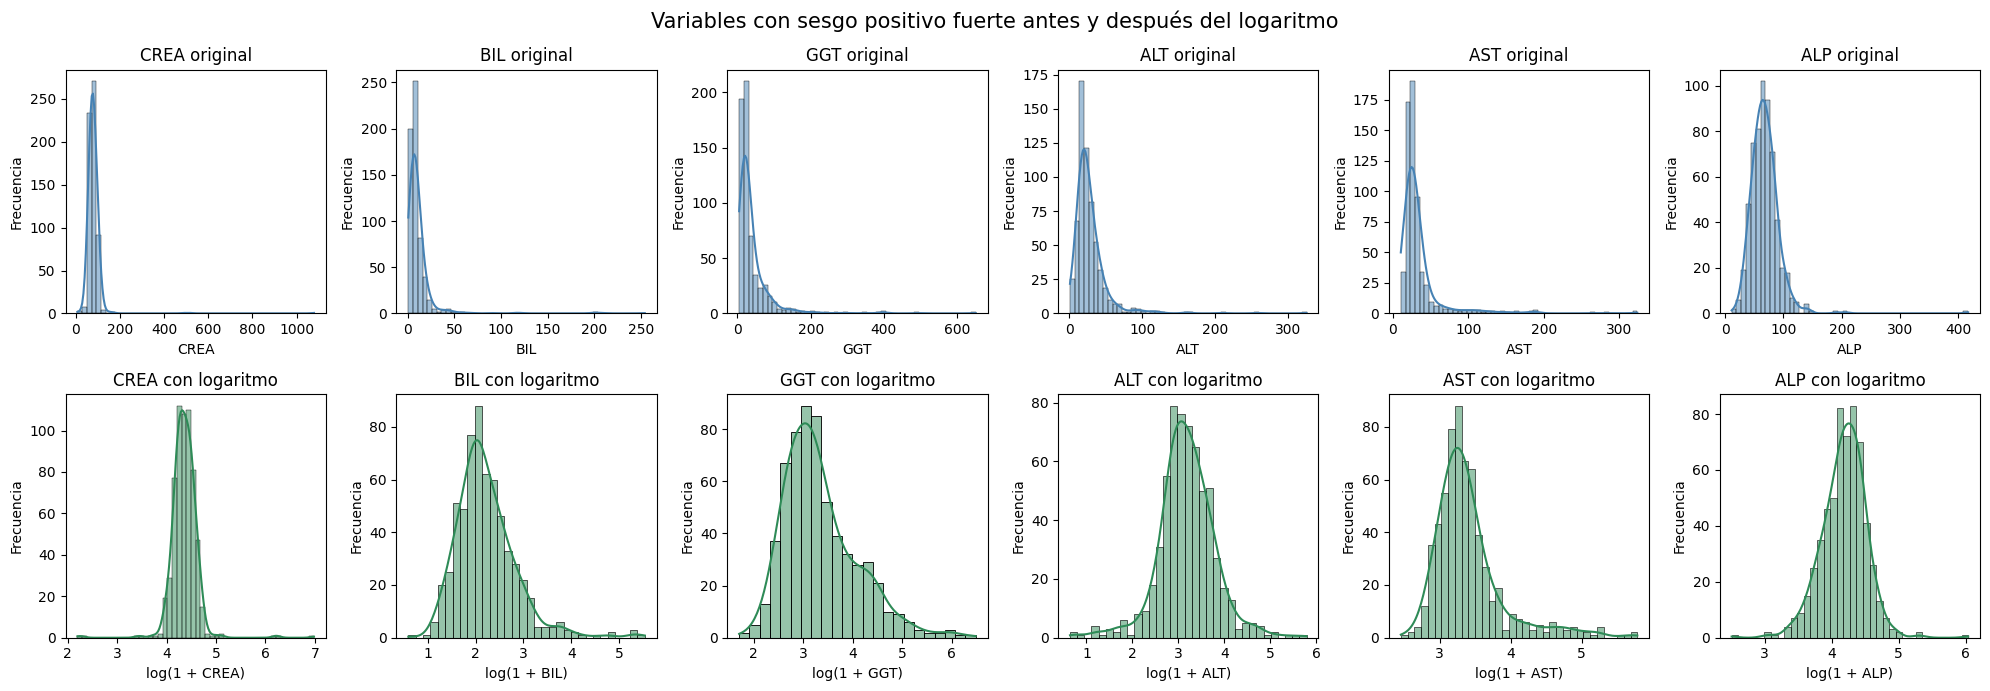

In [24]:
variables_sesgadas = forma.index[forma["Asimetria"] > 1].tolist()

fig, ejes = plt.subplots(2, len(variables_sesgadas), figsize=(20, 7))
for i, variable in enumerate(variables_sesgadas):
    sns.histplot(df[variable], kde=True, ax=ejes[0, i], color="steelblue")
    ejes[0, i].set_title(f"{variable} original")
    ejes[0, i].set_xlabel(variable)
    ejes[0, i].set_ylabel("Frecuencia")

    sns.histplot(np.log1p(df[variable]), kde=True, ax=ejes[1, i], color="seagreen")
    ejes[1, i].set_title(f"{variable} con logaritmo")
    ejes[1, i].set_xlabel(f"log(1 + {variable})")
    ejes[1, i].set_ylabel("Frecuencia")

fig.suptitle("Variables con sesgo positivo fuerte antes y después del logaritmo", fontsize=15)
plt.tight_layout()
plt.show()

El logaritmo baja mucho la asimetría en las seis variables sesgadas: `ALP` y `ALT` quedan prácticamente simétricas (-0.18 y -0.08), y `CREA` pasa de 15.17 a 0.87. `AST` y `BIL` mejoran, pero siguen con algo de sesgo (1.96 y 1.48).

En cambio, en las variables que ya eran simétricas (`ALB`, `CHE`, `PROT`) el logaritmo empeora la forma y las deja con sesgo negativo. Por eso, si se usa, sería solo para `ALP`, `ALT`, `AST`, `BIL`, `CREA` y `GGT`. Queda como propuesta para el preprocesamiento.

### Detección de valores atípicos

Implementamos los dos métodos con funciones propias, como en la práctica de la semana 4:

- **IQR:** un valor es atípico si está por debajo de Q1 - 1.5·IQR o por encima de Q3 + 1.5·IQR, donde IQR = Q3 - Q1. Es el mismo criterio que usa el boxplot para dibujar los puntos por fuera de los bigotes.
- **z-score:** z = (x - media) / desviación estándar. Tomamos como atípico todo valor con |z| > 3.

El z-score usa la media y la desviación estándar, que se dejan jalar por los valores extremos, y funciona mejor cuando la variable es más o menos normal. El IQR usa cuartiles, entonces es más confiable con variables sesgadas como las que acabamos de ver. Por eso el IQR es el método principal y el z-score queda como comparación.

In [25]:
def limites_iqr(serie, factor=1.5):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr


def atipicos_iqr(serie, factor=1.5):
    limite_inferior, limite_superior = limites_iqr(serie, factor)
    return (serie < limite_inferior) | (serie > limite_superior)


def atipicos_zscore(serie, umbral=3):
    z = (serie - serie.mean()) / serie.std()
    return z.abs() > umbral


filas_resumen = []
for variable in columnas_numericas:
    serie = df[variable]
    limite_inferior, limite_superior = limites_iqr(serie)
    total_iqr = atipicos_iqr(serie).sum()
    filas_resumen.append({
        "Variable": variable,
        "Limite_inferior": limite_inferior,
        "Limite_superior": limite_superior,
        "Atipicos_bajos": (serie < limite_inferior).sum(),
        "Atipicos_altos": (serie > limite_superior).sum(),
        "Total_IQR": total_iqr,
        "Porcentaje_IQR": total_iqr / serie.notna().sum() * 100,
        "Total_zscore": atipicos_zscore(serie).sum(),
    })

resumen_atipicos = (
    pd.DataFrame(filas_resumen)
    .set_index("Variable")
    .sort_values("Total_IQR", ascending=False)
)
display(resumen_atipicos.round(2))

,Limite_inferior,Limite_superior,Atipicos_bajos,Atipicos_altos,Total_IQR,Porcentaje_IQR,Total_zscore
Variable,,,,,,,
GGT,-21.05,76.95,0,65,65,10.57,10
AST,4.65,49.85,0,64,64,10.41,14
BIL,-3.55,20.05,0,47,47,7.64,7
ALT,-8.61,58.09,0,36,36,5.86,10
ALB,29.20,54.80,22,5,27,4.40,13
CHE,2.95,13.57,14,10,24,3.90,9
PROT,60.15,84.55,17,3,20,3.26,9
CREA,35.50,119.50,4,8,12,1.95,3
CHOL,2.44,8.24,2,10,12,1.98,7


- Las variables con más atípicos según el IQR son `GGT` (65), `AST` (64), `BIL` (47) y `ALT` (36), justo las que tienen sesgo positivo fuerte. En todas ellas los atípicos son solo altos.
- En `ALB`, `CHE` y `PROT` aparecen atípicos por los dos lados, pero sobre todo bajos.
- El z-score marca muchos menos casos (por ejemplo 14 en `AST` contra 64 del IQR). Pasa porque los mismos valores extremos inflan la desviación estándar y el umbral de |z| > 3 queda muy lejos. Esto confirma que en estas variables el z-score se queda corto.
- Algunos límites inferiores del IQR son negativos (`ALT`, `BIL`, `GGT`). Como un resultado de laboratorio no puede ser negativo, en esas variables solo puede haber atípicos altos.

#### ¿De quién son los valores atípicos?

Un valor atípico no es lo mismo que un error. Antes de decidir qué hacer con ellos, miramos a qué diagnóstico pertenecen: si son casi todos de pacientes enfermos, lo más probable es que sean valores reales causados por la enfermedad.

En los boxplots de abajo cada punto es un atípico según el IQR, pintado según el grupo del paciente. Juntamos hepatitis, fibrosis y cirrosis como "Paciente" para que el gráfico se lea más fácil.

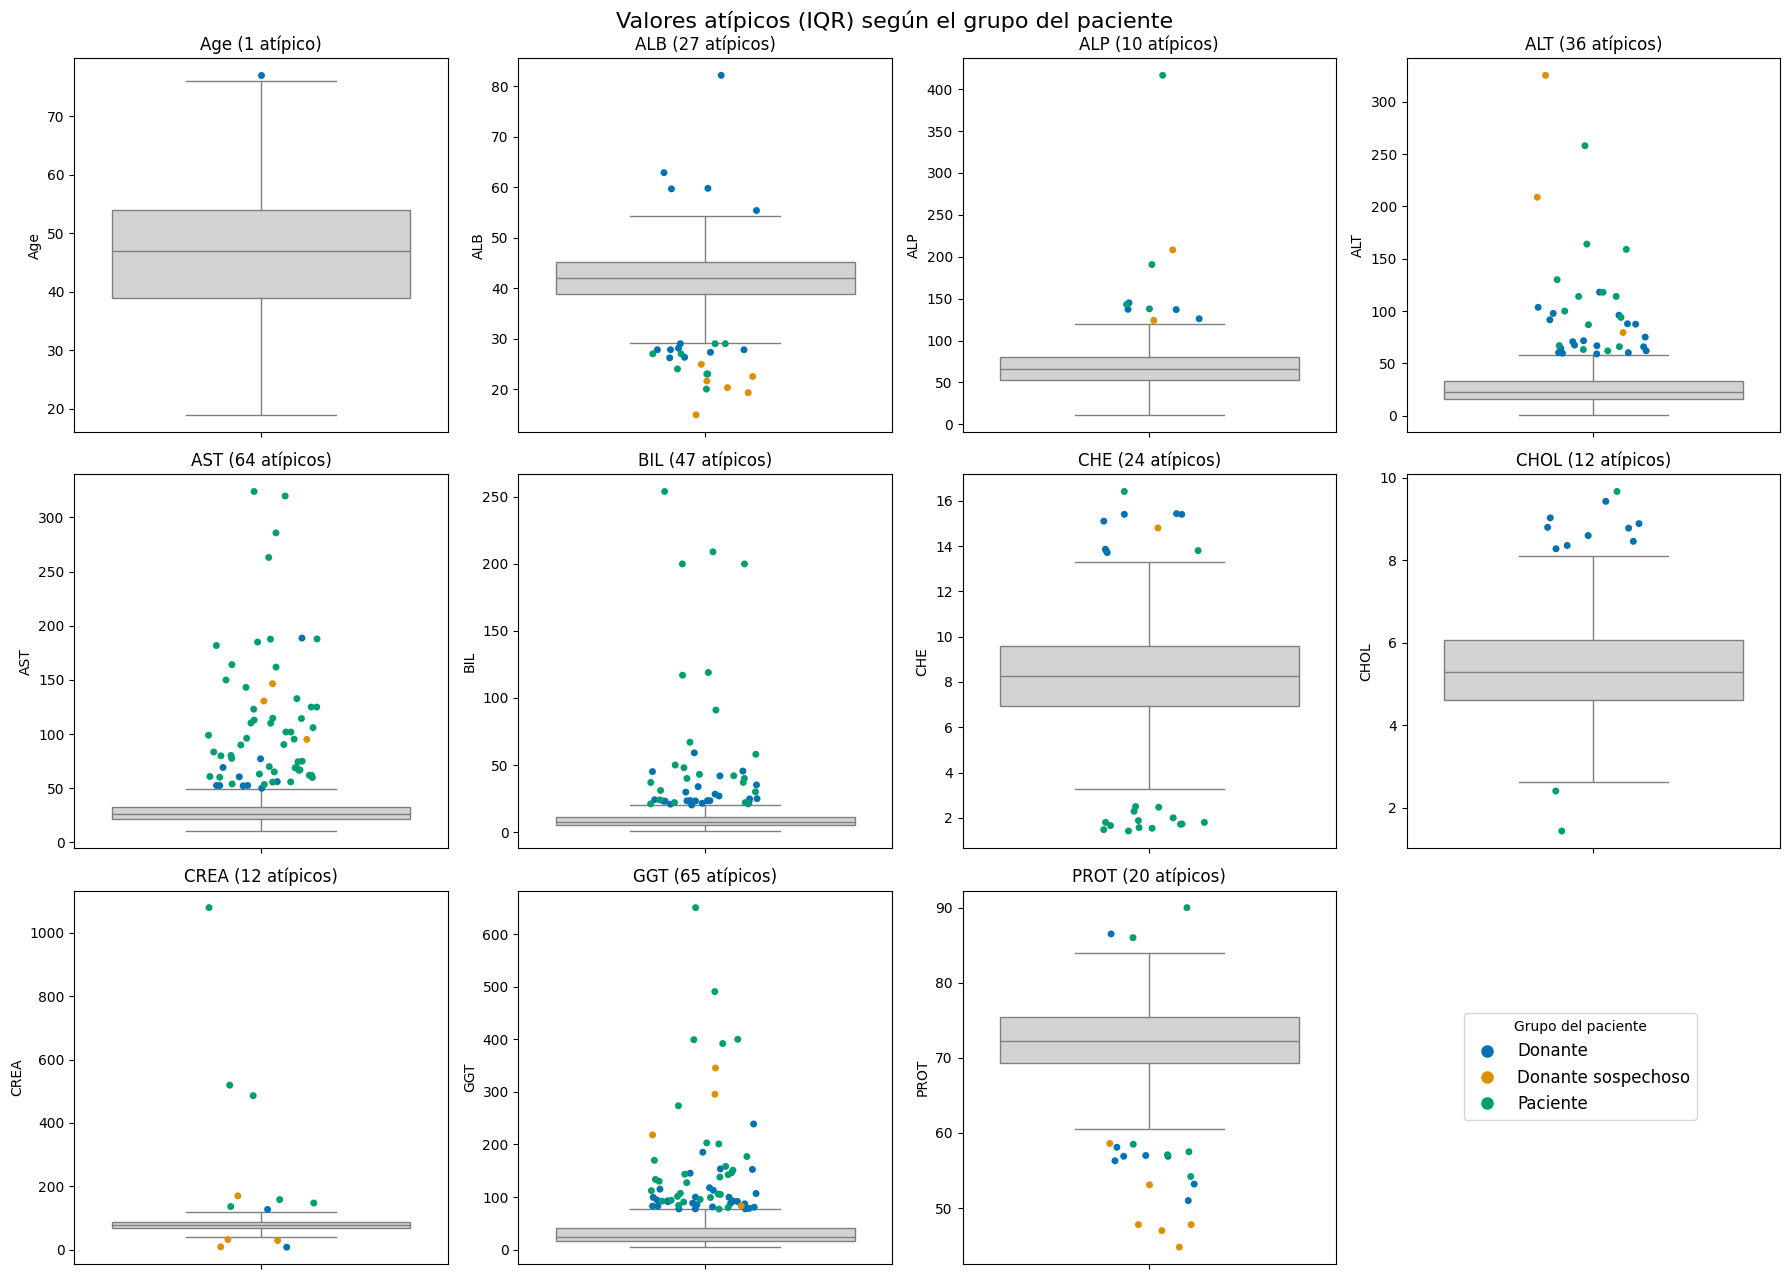

In [26]:
grupo = df["Category"].map({
    "0=Blood Donor": "Donante",
    "0s=suspect Blood Donor": "Donante sospechoso",
    "1=Hepatitis": "Paciente",
    "2=Fibrosis": "Paciente",
    "3=Cirrhosis": "Paciente",
})
orden_grupos = ["Donante", "Donante sospechoso", "Paciente"]
colores_grupo = dict(zip(orden_grupos, sns.color_palette("colorblind", len(orden_grupos))))

fig, ejes = plt.subplots(3, 4, figsize=(18, 13))
for eje, variable in zip(ejes.flat, columnas_numericas):
    serie = df[variable]
    es_atipico = atipicos_iqr(serie)
    sns.boxplot(y=serie, ax=eje, color="lightgray", showfliers=False)
    sns.stripplot(
        y=serie[es_atipico], hue=grupo[es_atipico], hue_order=orden_grupos,
        palette=colores_grupo, ax=eje, jitter=0.15, size=5, legend=False,
    )
    cantidad = es_atipico.sum()
    eje.set_title(f"{variable} ({cantidad} {'atípico' if cantidad == 1 else 'atípicos'})")
    eje.set_ylabel(variable)
for eje in ejes.flat[len(columnas_numericas):]:
    eje.set_visible(False)

fig.legend(
    handles=[
        plt.Line2D([], [], marker="o", linestyle="", color=colores_grupo[g], markersize=8)
        for g in orden_grupos
    ],
    labels=orden_grupos,
    title="Grupo del paciente",
    loc="lower right",
    bbox_to_anchor=(0.95, 0.12),
    fontsize=12,
)
fig.suptitle("Valores atípicos (IQR) según el grupo del paciente", fontsize=16)
plt.tight_layout()
fig.savefig(carpeta_imagenes / "atipicos_por_grupo.png", dpi=150)
plt.show()

In [27]:
atipicos_por_grupo = pd.DataFrame({
    variable: atipicos_iqr(df[variable]).groupby(grupo).sum()
    for variable in columnas_numericas
}).T
atipicos_por_grupo["Porcentaje_en_pacientes_y_sospechosos"] = (
    (atipicos_por_grupo["Paciente"] + atipicos_por_grupo["Donante sospechoso"])
    / atipicos_por_grupo[orden_grupos].sum(axis=1) * 100
)
display(atipicos_por_grupo.sort_values("Porcentaje_en_pacientes_y_sospechosos", ascending=False).round(1))

print(f"Pacientes y donantes sospechosos en el dataset: {grupo.ne('Donante').mean() * 100:.1f}%")

# Porcentaje de cada diagnóstico con al menos un valor atípico en alguna variable
tiene_atipico = pd.concat(
    [atipicos_iqr(df[variable]) for variable in columnas_numericas], axis=1
).any(axis=1)
display(
    (tiene_atipico.groupby(df["Category"]).mean() * 100)
    .round(1)
    .to_frame("Porcentaje_con_al_menos_un_atipico")
)

Category,Donante,Donante sospechoso,Paciente,Porcentaje_en_pacientes_y_sospechosos
AST,10,3,51,84.4
CREA,2,4,6,83.3
CHE,7,1,16,70.8
ALP,4,2,4,60.0
PROT,8,6,6,60.0
GGT,29,4,32,55.4
ALB,13,6,8,51.9
BIL,23,0,24,51.1
ALT,19,3,14,47.2
CHOL,9,0,3,25.0


Pacientes y donantes sospechosos en el dataset: 13.3%


,Porcentaje_con_al_menos_un_atipico
Category,
0=Blood Donor,18.2
0s=suspect Blood Donor,100.0
1=Hepatitis,62.5
2=Fibrosis,81.0
3=Cirrhosis,100.0


El resultado es bastante claro:

- En `AST`, 51 de los 64 atípicos son de pacientes con hepatitis, fibrosis o cirrosis, aunque ellos son solo 75 de 615 personas. En `CREA` (83.3 %) y `CHE` (70.8 %) también la mayoría de atípicos viene de pacientes o donantes sospechosos.
- En `GGT`, `BIL` y `ALT` la proporción está cerca de la mitad. Parece poco, pero pacientes y sospechosos juntos son solo el 13.3 % del dataset, así que están muy sobrerrepresentados entre los atípicos. La excepción es `CHOL`, donde el 75 % de los atípicos son de donantes sanos.
- El 100 % de los pacientes con cirrosis y de los donantes sospechosos tiene al menos un valor atípico, y lo mismo pasa con el 81 % de los de fibrosis y el 62.5 % de los de hepatitis. En los donantes sanos es apenas el 18.2 %.

O sea, buena parte de los atípicos no son ruido: son justamente la diferencia entre personas sanas y enfermas. Si los elimináramos, estaríamos borrando la información que más sirve para el resto del EDA y para ver separación entre grupos en el PCA.

#### Casos puntuales

Revisamos a mano los valores más extremos para decidir si parecen errores o valores reales.

In [28]:
# Valores más altos de creatinina
display(df.nlargest(5, "CREA")[[columna_id, "Category", "Age", "Sex", "CREA", "ALB", "GGT"]])

,Unnamed: 0,Category,Age,Sex,CREA,ALB,GGT
591,592,3=Cirrhosis,46,m,1079.1,35.0,105.6
586,587,3=Cirrhosis,39,m,519.0,34.0,133.4
606,607,3=Cirrhosis,49,f,485.9,33.0,112.0
533,534,0s=suspect Blood Donor,47,m,170.0,22.5,345.6
607,608,3=Cirrhosis,52,f,158.2,39.0,142.5


In [29]:
# La albúmina es una parte de la proteína total, así que ALB no debería ser mayor que PROT
display(df[df["ALB"] > df["PROT"]][[columna_id, "Category", "Age", "Sex", "ALB", "PROT"]])

# Proporción ALB / PROT en todo el dataset, para comparar
display((df["ALB"] / df["PROT"]).describe().round(2).to_frame("ALB/PROT"))

,Unnamed: 0,Category,Age,Sex,ALB,PROT
216,217,0=Blood Donor,52,m,82.2,67.4


,ALB/PROT
count,613.00
mean,0.58
std,0.07
min,0.32
25%,0.54
50%,0.58
75%,0.61
max,1.22


In [30]:
# Valores más bajos de albúmina
display(df.nsmallest(5, "ALB")[[columna_id, "Category", "Age", "Sex", "ALB", "PROT"]])

# Diagnóstico de los atípicos bajos de CHE
limite_inferior_che, _ = limites_iqr(df["CHE"])
display(
    df.loc[df["CHE"] < limite_inferior_che, "Category"]
    .value_counts()
    .to_frame("Atipicos_bajos_de_CHE")
)

,Unnamed: 0,Category,Age,Sex,ALB,PROT
537,538,0s=suspect Blood Donor,71,m,14.9,47.0
539,540,0s=suspect Blood Donor,59,f,19.3,53.1
590,591,3=Cirrhosis,46,m,20.0,NaN
538,539,0s=suspect Blood Donor,74,m,20.3,47.8
535,536,0s=suspect Blood Donor,49,m,21.6,44.8


,Atipicos_bajos_de_CHE
Category,
3=Cirrhosis,14


- **`CREA` de 1079.1, 519 y 485.9:** son unas 6 a 14 veces la mediana (77), pero los tres son pacientes con cirrosis. Parecen valores extremos reales de pacientes graves, no errores. Se conservan, y como `CREA` es la variable más sesgada, es la principal candidata a la transformación logarítmica.
- **`ALB` de 82.2 en el registro 217:** es un donante sano y su `PROT` es 67.4. La albúmina no puede ser mayor que la proteína total, y en el dataset la proporción `ALB/PROT` tiene mediana de 0.58 y en el 75 % de los registros no pasa de 0.61, mientras que aquí da 1.22. Además, el siguiente valor más alto de `ALB` es 62.9. **Este sí parece un error de digitación.**
- **`ALB` bajos (14.9, 19.3, 20.0...):** de los 5 más bajos, 4 son donantes sospechosos y el otro es un paciente con cirrosis. Los donantes sospechosos también tienen `PROT` bajo (entre 44.8 y 53.1), entonces los dos valores cuadran entre sí y parecen reales.
- **`CHE` muy bajos (el grupito que se veía en el histograma):** los 14 atípicos bajos de `CHE` (entre 1.42 y 2.5) son todos de pacientes con cirrosis, así que ese grupito corresponde a la enfermedad y no a un error.
- **`ALT` muy bajos en cirrosis (0.9, 1.2, 1.3):** están dentro del rango del IQR y solo los tienen pacientes con cirrosis, así que no los tomamos como error.
- **`Age` de 77:** es el único atípico de edad y apenas pasa el límite de 76.5. Es una edad totalmente posible, se conserva.

### Decisión sobre los valores atípicos

**No eliminamos atípicos de forma automática.** La decisión depende de cada variable:

| Variable | Forma | Atípicos (IQR) | Diagnóstico | Decisión |
|---|---|---:|---|---|
| `Age` | Aproximadamente simétrica | 1 | Valor válido | Conservar |
| `ALB` | Simétrica, colas pesadas | 27 | Un error claro (82.2) y el resto válidos | Pasar el 82.2 a faltante e imputarlo como los demás faltantes; conservar el resto |
| `ALP` | Sesgo positivo fuerte | 10 | Valores extremos válidos | Conservar, posible logaritmo |
| `ALT` | Sesgo positivo fuerte | 36 | Valores extremos válidos | Conservar, posible logaritmo |
| `AST` | Sesgo positivo fuerte | 64 | Casi todos de pacientes | Conservar, posible logaritmo |
| `BIL` | Sesgo positivo fuerte | 47 | Valores extremos válidos | Conservar, posible logaritmo |
| `CHE` | Aproximadamente simétrica | 24 | Bajos en pacientes con cirrosis | Conservar |
| `CHOL` | Aproximadamente simétrica | 12 | Valores posibles | Conservar |
| `CREA` | Sesgo positivo muy fuerte | 12 | Extremos de pacientes con cirrosis | Conservar, logaritmo recomendado |
| `GGT` | Sesgo positivo fuerte | 65 | Valores extremos válidos | Conservar, posible logaritmo |
| `PROT` | Sesgo negativo moderado | 20 | Bajos en donantes sospechosos | Conservar |

**Para el preprocesamiento (notebook 03):**

- El `ALB` de 82.2 del registro 217 se puede pasar a faltante y tratarlo con la misma estrategia que se propuso en la sección de calidad (mediana por grupo diagnóstico).
- Aplicar logaritmo a `ALP`, `ALT`, `AST`, `BIL`, `CREA` y `GGT` es opcional, pero ayudaría a que esas variables no dominen el análisis por sus colas.
- Los 7 donantes sospechosos tienen valores más parecidos a los de los pacientes que a los de los donantes sanos. Esto apoya lo que quedó pendiente en la sección de calidad sobre cómo tratar esa categoría, y vale la pena mirarlo también en el análisis bivariado.
- Como los atípicos se conservan, para el escalado conviene `StandardScaler` y no `MinMaxScaler`: con `MinMaxScaler` un solo valor como el `CREA` de 1079.1 dejaría a casi todos los demás pacientes apretados en una franja muy pequeña del rango de 0 a 1.

## Análisis bivariado, multivariado y correlaciones

En esta sección estudiamos cómo se relacionan las variables clínicas entre sí y cómo cambian según el diagnóstico y el sexo. Para las variables cuantitativas usamos correlaciones de **Pearson** y **Spearman**: Pearson resume relaciones lineales, mientras que Spearman detecta relaciones monótonas y es menos sensible a las distribuciones sesgadas y a los valores extremos encontrados anteriormente.

La primera columna se mantiene fuera del análisis porque es solo un identificador. `Category` y `Sex` tampoco entran en las matrices de correlación: aunque puedan codificarse con números, son variables nominales y esos números introducirían un orden artificial.

In [ ]:
# Pearson y Spearman se calculan solo entre variables cuantitativas.
matriz_pearson = df[columnas_numericas].corr(method="pearson")
matriz_spearman = df[columnas_numericas].corr(method="spearman")

def correlaciones_ordenadas(matriz):
    mascara_superior = np.triu(
        np.ones(matriz.shape, dtype=bool), k=1
    )
    pares = matriz.where(mascara_superior).stack().rename("Correlacion")
    resultado = pares.to_frame()
    resultado["Correlacion_absoluta"] = resultado["Correlacion"].abs()
    return resultado.sort_values("Correlacion_absoluta", ascending=False)

correlaciones_pearson = correlaciones_ordenadas(matriz_pearson)
correlaciones_spearman = correlaciones_ordenadas(matriz_spearman)

print("Diez relaciones más fuertes según Pearson:")
display(correlaciones_pearson.head(10).round(3))
print("Diez relaciones más fuertes según Spearman:")
display(correlaciones_spearman.head(10).round(3))

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(20, 8))
for eje, matriz, metodo in zip(
    ejes,
    [matriz_pearson, matriz_spearman],
    ["Pearson", "Spearman"],
):
    sns.heatmap(
        matriz, annot=True, fmt=".2f", cmap="coolwarm",
        center=0, vmin=-1, vmax=1, square=True,
        linewidths=0.4, ax=eje,
    )
    eje.set_title(f"Matriz de correlación de {metodo}")
fig.suptitle("Relaciones entre variables cuantitativas", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

### Interpretación de las correlaciones

- La relación positiva más alta en Pearson es `ALB–PROT` (**0.557**) y también es la más alta en Spearman (**0.514**). Es coherente que aumenten juntas porque la albúmina forma parte de la proteína total, aunque la asociación no es perfecta porque `PROT` incluye otras proteínas.
- `AST–GGT` presenta una asociación positiva moderada y estable en ambos métodos (Pearson **0.491**, Spearman **0.505**). Las dos mediciones tienden a aumentar conjuntamente, especialmente dentro de los grupos clínicos.
- `ALT–AST` cambia de **0.273** en Pearson a **0.497** en Spearman. Esta diferencia concuerda con su fuerte sesgo y sus valores extremos: existe una tendencia monótona clara, pero no queda bien resumida por una recta en la escala original.
- `CHE–CHOL` mantiene una relación positiva moderada (Pearson **0.426**, Spearman **0.400**). `ALB–CHE` también es positiva, mientras que `BIL–CHE` es negativa en Pearson (**-0.333**), lo que sugiere perfiles bioquímicos diferentes entre los grupos.
- Ninguna correlación alcanza una magnitud que indique redundancia casi total. Además, estas asociaciones no demuestran causalidad y pueden estar influidas por diagnóstico, sexo, valores extremos u otras variables no incluidas.

### Diagramas de dispersión

Visualizamos cuatro pares destacados y diferenciamos tres grupos: donantes, donantes sospechosos y pacientes. Para los pares formados por pruebas con sesgo positivo fuerte se usan ejes logarítmicos únicamente para facilitar la lectura; los datos originales no se modifican.

In [ ]:
df_relaciones = df.copy()
df_relaciones["Grupo_clinico"] = df_relaciones["Category"].map({
    "0=Blood Donor": "Donante",
    "0s=suspect Blood Donor": "Donante sospechoso",
    "1=Hepatitis": "Paciente",
    "2=Fibrosis": "Paciente",
    "3=Cirrhosis": "Paciente",
})

pares_dispersion = [
    ("ALB", "PROT", False),
    ("AST", "GGT", True),
    ("ALT", "AST", True),
    ("CHE", "CHOL", False),
]

fig, ejes = plt.subplots(2, 2, figsize=(15, 11))
for eje, (variable_x, variable_y, escala_log) in zip(ejes.flat, pares_dispersion):
    sns.scatterplot(
        data=df_relaciones, x=variable_x, y=variable_y,
        hue="Grupo_clinico", hue_order=orden_grupos,
        palette=colores_grupo, alpha=0.7, s=45, ax=eje,
    )
    if escala_log:
        eje.set_xscale("log")
        eje.set_yscale("log")
    eje.set_title(f"{variable_x} frente a {variable_y}")
    eje.set_xlabel(variable_x)
    eje.set_ylabel(variable_y)
    eje.legend(title="Grupo clínico", fontsize=8)
fig.suptitle("Relaciones bivariadas destacadas", fontsize=16)
fig.tight_layout()
plt.show()

Los diagramas confirman que las correlaciones no describen por sí solas toda la estructura. `ALB–PROT` y `CHE–CHOL` muestran tendencias ascendentes relativamente compactas entre los donantes. En `AST–GGT` y `ALT–AST` los pacientes ocupan con mayor frecuencia la zona de valores altos, mientras que los donantes se concentran en valores bajos. Por tanto, parte de la asociación global puede provenir de la separación entre grupos diagnósticos. El caso aislado con `ALB = 82.2`, ya discutido como posible error, también se distingue con claridad y explica por qué conviene interpretar Pearson con cautela.

### Comparación de variables clínicas por diagnóstico

Los boxplots agrupados permiten relacionar una variable cuantitativa con la categoría diagnóstica. Se muestran marcadores atenuados y, para las variables muy sesgadas, escala logarítmica. Las medianas se presentan aparte para facilitar comparaciones exactas.

In [ ]:
etiquetas_diagnostico = {
    "0=Blood Donor": "Donante",
    "0s=suspect Blood Donor": "Sospechoso",
    "1=Hepatitis": "Hepatitis",
    "2=Fibrosis": "Fibrosis",
    "3=Cirrhosis": "Cirrosis",
}
df_relaciones["Diagnostico"] = df_relaciones["Category"].map(etiquetas_diagnostico)
orden_diagnostico = list(etiquetas_diagnostico.values())
variables_por_diagnostico = ["ALB", "AST", "BIL", "CHE", "GGT"]

fig, ejes = plt.subplots(2, 3, figsize=(18, 10))
for eje, variable in zip(ejes.flat, variables_por_diagnostico):
    sns.boxplot(
        data=df_relaciones, x="Diagnostico", y=variable,
        order=orden_diagnostico, color="lightsteelblue",
        showfliers=True, ax=eje,
    )
    if variable in ["AST", "BIL", "GGT"]:
        eje.set_yscale("log")
    eje.set_title(f"{variable} según diagnóstico")
    eje.set_xlabel("Diagnóstico")
    eje.set_ylabel(variable)
    eje.tick_params(axis="x", rotation=30)
for eje in ejes.flat[len(variables_por_diagnostico):]:
    eje.set_visible(False)
fig.tight_layout()
plt.show()

medianas_por_diagnostico = (
    df_relaciones.groupby("Diagnostico", observed=False)[
        variables_por_diagnostico
    ]
    .median()
    .reindex(orden_diagnostico)
)
display(medianas_por_diagnostico.round(2))

Los perfiles cambian de forma importante entre diagnósticos. La mediana de `AST` crece desde **24.8** en donantes hasta **70.0** en fibrosis y **92.9** en cirrosis; `GGT` pasa de **21.4** a **72.2** y **96.35**, respectivamente. En cirrosis, `BIL` alcanza una mediana de **34.0**, mientras `ALB` baja a **33.0** y `CHE` a **3.42**. Los donantes sospechosos también presentan un perfil particular: `ALB` tiene una mediana de **21.6** y `GGT` de **83.0**.

Estas diferencias convierten a `AST`, `GGT`, `BIL`, `ALB` y `CHE` en variables potencialmente relevantes para distinguir grupos. Sin embargo, los tamaños son muy desiguales —533 donantes frente a solo 7 sospechosos—, por lo que los patrones de las categorías pequeñas deben considerarse exploratorios y no conclusiones definitivas.

### Tabla cruzada entre diagnóstico y sexo

Para estudiar la relación entre las dos variables categóricas construimos una tabla de frecuencias y otra de porcentajes por diagnóstico. En este commit solo describimos la asociación observada; una prueba formal de independencia corresponde a la etapa de hipótesis.

In [ ]:
tabla_sexo_diagnostico = pd.crosstab(
    df_relaciones["Diagnostico"], df_relaciones["Sex"]
).reindex(orden_diagnostico)
porcentaje_sexo_diagnostico = (
    pd.crosstab(
        df_relaciones["Diagnostico"], df_relaciones["Sex"],
        normalize="index",
    )
    .mul(100)
    .reindex(orden_diagnostico)
)

print("Frecuencias absolutas:")
display(tabla_sexo_diagnostico)
print("Porcentajes dentro de cada diagnóstico:")
display(porcentaje_sexo_diagnostico.round(1))

porcentaje_sexo_diagnostico.rename(columns={"f": "Mujeres", "m": "Hombres"}).plot(
    kind="bar", stacked=True, figsize=(11, 6),
    color=["#DD8452", "#4C72B0"],
)
plt.title("Composición por sexo dentro de cada diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("Porcentaje dentro de la categoría")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Sexo")
plt.tight_layout()
plt.show()

Los hombres son mayoría en todas las categorías: representan **59.7%** de los donantes, **85.7%** de los sospechosos, **83.3%** de hepatitis, **61.9%** de fibrosis y **66.7%** de cirrosis. La diferencia es especialmente grande en sospechosos y hepatitis, pero esos grupos tienen pocos registros. Esta composición puede actuar como factor de confusión al comparar pruebas de laboratorio por diagnóstico; por ello, una diferencia entre categorías no debe atribuirse automáticamente solo a la enfermedad.

### Vista multivariada

El pairplot reúne cinco variables que mostraron diferencias por diagnóstico y relaciones relevantes. Se usan los tres grupos clínicos generales para evitar una leyenda excesiva y para observar si las combinaciones de variables producen separación entre donantes y pacientes.

In [ ]:
variables_pairplot = ["ALB", "AST", "BIL", "CHE", "GGT"]
datos_pairplot = df_relaciones[variables_pairplot + ["Grupo_clinico"]].dropna()

grafico_pares = sns.pairplot(
    datos_pairplot, vars=variables_pairplot, hue="Grupo_clinico",
    hue_order=orden_grupos, palette=colores_grupo,
    corner=True, diag_kind="hist",
    plot_kws={"alpha": 0.55, "s": 24},
    diag_kws={"alpha": 0.55},
)
grafico_pares.fig.suptitle(
    "Patrones multivariados según el grupo clínico", y=1.02, fontsize=16
)
plt.show()

La vista conjunta muestra que no hay una única variable que separe perfectamente los grupos. Aun así, muchos pacientes se desplazan hacia combinaciones de `AST`, `BIL` y `GGT` altas junto con `ALB` y `CHE` bajas, mientras los donantes se concentran en la región opuesta. Los donantes sospechosos se superponen parcialmente con los pacientes, en línea con los valores atípicos observados antes. Esto sugiere que una combinación de variables puede ser más informativa que cualquiera de ellas por separado, aunque el fuerte desbalance de clases impide afirmar que exista una separación definitiva.

### Conclusiones del análisis de relaciones

1. `ALB–PROT`, `AST–GGT`, `ALT–AST` y `CHE–CHOL` son las asociaciones cuantitativas más consistentes, pero ninguna implica causalidad.
2. La diferencia entre Pearson y Spearman en variables sesgadas confirma que los valores extremos y las relaciones no lineales afectan la correlación lineal.
3. `AST`, `GGT` y `BIL` tienden a ser mayores en fibrosis y cirrosis, mientras `ALB` y `CHE` tienden a ser menores en cirrosis.
4. Las combinaciones de varias pruebas muestran más separación entre donantes y pacientes que una variable aislada.
5. El desbalance diagnóstico y la composición por sexo obligan a interpretar las comparaciones con cautela. Estos patrones sirven como base para formular hipótesis posteriores, pero aquí no se realizan pruebas inferenciales ni se afirma causalidad.

## Construcción y validación de hipótesis

Hasta acá describimos los datos y encontramos varios patrones, pero como vimos en la guía de la semana 6, falta responder una pregunta clave: **¿esas diferencias son reales o pueden ser producto del azar?** Para eso usamos pruebas de hipótesis.

Las hipótesis que planteamos no son inventadas: cada una sale de un patrón que ya observamos en las secciones anteriores del EDA. Para todas seguimos el mismo procedimiento de la guía:

1. Plantear la hipótesis nula (H0) y la alternativa (H1).
2. Fijar el nivel de significancia **α = 0.05**, es decir, aceptamos un 5% de probabilidad de cometer un error tipo I (rechazar H0 cuando en realidad es verdadera).
3. Calcular el estadístico de prueba y el **p-valor**.
4. Decidir: si p < α se rechaza H0; si p ≥ α **no se rechaza** H0. Ojo que no decimos que se "acepta" H0, porque no tener evidencia suficiente contra ella no demuestra que sea cierta.
5. Interpretar el resultado en el contexto del dataset.

Para comparar donantes contra pacientes usamos la variable `Grupo_clinico` que se creó en el análisis bivariado, donde Hepatitis, Fibrosis y Cirrosis quedan juntas como *Paciente*. Dejamos por fuera a los 7 donantes sospechosos, porque son muy pocos para sacar conclusiones y además quedó pendiente decidir cómo tratarlos.

In [ ]:
from scipy import stats

alfa = 0.05

def decidir(p_valor, alfa=0.05):
    # Regla de decisión de la guía: se rechaza H0 solo si el p-valor es menor que alfa
    if p_valor < alfa:
        return "Se rechaza H0"
    return "No se rechaza H0"

donantes = df_relaciones[df_relaciones["Grupo_clinico"] == "Donante"]
pacientes = df_relaciones[df_relaciones["Grupo_clinico"] == "Paciente"]
print(f"Donantes: {len(donantes)} registros")
print(f"Pacientes (hepatitis, fibrosis y cirrosis): {len(pacientes)} registros")

### Hipótesis 1: la AST es diferente entre donantes y pacientes

**De dónde sale:** en el análisis bivariado vimos que la mediana de `AST` sube de 24.8 en los donantes hasta 70.0 en fibrosis y 92.9 en cirrosis, y en los diagramas de dispersión los pacientes ocupan la zona de valores altos.

- **H0:** la media de `AST` es igual en donantes y pacientes.
- **H1:** la media de `AST` es diferente entre donantes y pacientes (prueba bilateral).
- **Prueba:** t de Student para dos muestras independientes, porque comparamos las medias de una variable cuantitativa entre dos grupos.

**Supuesto de normalidad:** la guía de la semana 6 recuerda que la prueba t supone datos aproximadamente normales, y en la sección de distribuciones encontramos que `AST` tiene un sesgo positivo fuerte. Por eso aplicamos la prueba sobre el **logaritmo de AST**, que fue la transformación que en esa misma sección redujo la asimetría. Además, como las dos muestras tienen dispersiones muy distintas, usamos la versión de la prueba t que no supone varianzas iguales (`equal_var=False`).

In [ ]:
ast_donantes = donantes["AST"].dropna()
ast_pacientes = pacientes["AST"].dropna()

print("Asimetría de AST antes y después del logaritmo:")
display(pd.DataFrame({
    "Original": [ast_donantes.skew(), ast_pacientes.skew()],
    "Logaritmo": [np.log(ast_donantes).skew(), np.log(ast_pacientes).skew()],
}, index=["Donantes", "Pacientes"]).round(2))

print("Desviación estándar de AST:")
print(f"  Donantes: {ast_donantes.std():.2f} | Pacientes: {ast_pacientes.std():.2f}")

prueba_ast = stats.ttest_ind(np.log(ast_donantes), np.log(ast_pacientes), equal_var=False)
print(f"\nMedia de AST en donantes: {ast_donantes.mean():.2f}")
print(f"Media de AST en pacientes: {ast_pacientes.mean():.2f}")
print(f"Estadístico t: {prueba_ast.statistic:.3f}")
print(f"p-valor: {prueba_ast.pvalue:.3e}")
print(f"Decisión con alfa = {alfa}: {decidir(prueba_ast.pvalue, alfa)}")

**Interpretación:** el logaritmo bajó bastante la asimetría (sobre todo en los donantes), así que el supuesto de normalidad queda mucho mejor cubierto. El p-valor es muchísimo menor que 0.05, entonces **rechazamos H0**: hay evidencia estadística de que la `AST` es diferente entre donantes y pacientes. El estadístico t es negativo porque la media de los donantes es menor; en promedio los pacientes tienen una `AST` de unas 90 unidades frente a unas 27 en los donantes.

Esto confirma lo que ya se veía en los boxplots: la diferencia no es casualidad de la muestra. Aun así, esta prueba no dice que la `AST` alta *cause* la enfermedad ni al revés; solo dice que los dos grupos se comportan distinto en esta variable.

### Hipótesis 2: la albúmina es diferente entre donantes y pacientes

**De dónde sale:** en el análisis bivariado la mediana de `ALB` baja a 33.0 en los pacientes con cirrosis, y en el pairplot muchos pacientes aparecen en la zona de `ALB` baja.

- **H0:** la media de `ALB` es igual en donantes y pacientes.
- **H1:** la media de `ALB` es diferente entre donantes y pacientes (prueba bilateral).
- **Prueba:** t de Student para dos muestras independientes, sin suponer varianzas iguales.

A diferencia de `AST`, la albúmina tiene una distribución aproximadamente simétrica, así que aquí **no** hace falta transformarla. Hay un detalle: en la sección de valores atípicos se identificó el `ALB` de 82.2 como un posible error. Como la corrección se aplica en el notebook 03, corremos la prueba con los datos originales y repetimos el cálculo sin ese valor para ver si cambia la decisión.

In [ ]:
alb_donantes = donantes["ALB"].dropna()
alb_pacientes = pacientes["ALB"].dropna()

prueba_alb = stats.ttest_ind(alb_donantes, alb_pacientes, equal_var=False)
print(f"Media de ALB en donantes: {alb_donantes.mean():.2f}")
print(f"Media de ALB en pacientes: {alb_pacientes.mean():.2f}")
print(f"Estadístico t: {prueba_alb.statistic:.3f}")
print(f"p-valor: {prueba_alb.pvalue:.3e}")
print(f"Decisión con alfa = {alfa}: {decidir(prueba_alb.pvalue, alfa)}")

# Revisión de sensibilidad: misma prueba sin el valor de ALB = 82.2
prueba_alb_sin_error = stats.ttest_ind(
    alb_donantes[alb_donantes != 82.2], alb_pacientes, equal_var=False
)
print(f"\nSin el ALB = 82.2 -> t: {prueba_alb_sin_error.statistic:.3f}, "
      f"p-valor: {prueba_alb_sin_error.pvalue:.3e}, "
      f"{decidir(prueba_alb_sin_error.pvalue, alfa)}")

**Interpretación:** el p-valor es menor que 0.05, así que **rechazamos H0**: la albúmina media de los pacientes (alrededor de 38.8) es diferente a la de los donantes (alrededor de 42.2). En este caso el t es positivo porque ahora son los donantes los que tienen el valor más alto.

La diferencia en unidades es más pequeña que en la `AST`, pero sigue siendo significativa. Y cuando quitamos el `ALB` de 82.2 la decisión no cambia, o sea que el resultado no depende de ese posible error. Este resultado va en la misma dirección que lo observado en el EDA: los pacientes tienden a tener la albúmina más baja.

### Hipótesis 3: el sexo está asociado con ser donante o paciente

**De dónde sale:** en la tabla cruzada del análisis bivariado vimos que los hombres son mayoría en todas las categorías, pero con porcentajes distintos (59.7% en donantes frente a porcentajes más altos en hepatitis y cirrosis). En esa sección se dejó explícitamente la prueba formal de independencia para esta etapa.

- **H0:** el sexo y el grupo clínico (donante o paciente) son independientes.
- **H1:** existe asociación entre el sexo y el grupo clínico.
- **Prueba:** chi-cuadrado de independencia, que según la guía de la semana 6 es la adecuada cuando las dos variables son categóricas.

Agrupamos los tres diagnósticos en *Paciente* y dejamos por fuera a los sospechosos porque, con las cinco categorías originales, varias celdas tendrían frecuencias esperadas muy pequeñas (por ejemplo, solo unas 3 mujeres esperadas entre los sospechosos), y así la prueba no sería confiable.

In [ ]:
datos_chi = df_relaciones[df_relaciones["Grupo_clinico"].isin(["Donante", "Paciente"])]
tabla_chi = pd.crosstab(datos_chi["Grupo_clinico"], datos_chi["Sex"])
print("Frecuencias observadas:")
display(tabla_chi)
print("Porcentaje de hombres en cada grupo:")
display(pd.crosstab(datos_chi["Grupo_clinico"], datos_chi["Sex"], normalize="index")["m"].mul(100).round(1))

prueba_chi = stats.chi2_contingency(tabla_chi, correction=False)
print("Frecuencias esperadas si H0 fuera cierta:")
display(pd.DataFrame(prueba_chi.expected_freq, index=tabla_chi.index, columns=tabla_chi.columns).round(2))
print(f"Estadístico chi-cuadrado: {prueba_chi.statistic:.3f}")
print(f"Grados de libertad: {prueba_chi.dof}")
print(f"p-valor: {prueba_chi.pvalue:.4f}")
print(f"Decisión con alfa = {alfa}: {decidir(prueba_chi.pvalue, alfa)}")

**Interpretación:** todas las frecuencias esperadas quedaron por encima de 5, así que la prueba es válida. El p-valor es mayor que 0.05, entonces **no rechazamos H0**: con estos datos no hay evidencia suficiente para decir que el sexo está asociado con ser donante o paciente.

Este resultado es interesante porque en la tabla sí se ve una diferencia (los pacientes tienen un porcentaje de hombres más alto que los donantes), pero la prueba nos dice que esa diferencia **puede explicarse por el azar**. Es justo el caso que plantea la guía: una diferencia observada que no es estadísticamente significativa.

Hay que tener en cuenta que solo hay 75 pacientes, y con muestras pequeñas la prueba tiene menos potencia para detectar diferencias reales. Por eso no podemos afirmar que el sexo no influya; lo correcto es decir que no encontramos evidencia suficiente, y existe la posibilidad de estar cometiendo un error tipo II. En la práctica, esto significa que el sexo no debería tratarse como un factor de confusión fuerte, aunque vale la pena tenerlo presente.

### Hipótesis 4: existe correlación entre la albúmina y la proteína total

**De dónde sale:** `ALB–PROT` fue la correlación más alta tanto en Pearson (0.557) como en Spearman (0.514), y en el diagrama de dispersión se ve una tendencia ascendente.

- **H0:** la correlación poblacional entre `ALB` y `PROT` es cero (ρ = 0).
- **H1:** la correlación poblacional es distinta de cero (ρ ≠ 0).
- **Prueba:** prueba t para la correlación de Pearson, con el estadístico de la guía de la semana 4:

$$t = r \cdot \sqrt{\frac{n-2}{1-r^2}}$$

donde *r* es la correlación muestral y *n* el número de observaciones, con *n − 2* grados de libertad. Calculamos el estadístico con la fórmula de la guía y comparamos el p-valor con el que da `scipy`, para verificar que el cálculo esté bien.

In [ ]:
datos_correlacion = df[["ALB", "PROT"]].dropna()
n = len(datos_correlacion)
r = datos_correlacion["ALB"].corr(datos_correlacion["PROT"], method="pearson")

# Estadístico de prueba de la guía de la semana 4
t_correlacion = r * np.sqrt((n - 2) / (1 - r ** 2))
p_valor_correlacion = 2 * stats.t.sf(abs(t_correlacion), df=n - 2)

print(f"n = {n}")
print(f"r de Pearson = {r:.3f}")
print(f"Estadístico t = {t_correlacion:.3f}")
print(f"p-valor (fórmula de la guía) = {p_valor_correlacion:.3e}")

verificacion = stats.pearsonr(datos_correlacion["ALB"], datos_correlacion["PROT"])
print(f"p-valor con scipy.stats.pearsonr = {verificacion.pvalue:.3e}")
print(f"Decisión con alfa = {alfa}: {decidir(p_valor_correlacion, alfa)}")

**Interpretación:** el p-valor calculado con la fórmula de la guía coincide con el de `scipy`, así que el cálculo está bien hecho. Como es prácticamente cero, **rechazamos H0**: la correlación entre albúmina y proteína total es significativamente distinta de cero. El valor de r = 0.557 indica una relación positiva de intensidad moderada: cuando una sube, la otra tiende a subir.

Tiene sentido, porque la albúmina es una de las proteínas que se miden dentro de la proteína total. Pero hay que tener en cuenta dos cosas: primero, que la correlación sea significativa no quiere decir que sea fuerte (con 613 registros, hasta correlaciones pequeñas salen significativas, porque el tamaño de la muestra influye directamente en el p-valor); y segundo, correlación no es causalidad. Como r está lejos de 1, las dos variables no son redundantes y conviene conservar ambas para las siguientes fases.

### Resumen de las hipótesis

In [ ]:
resumen_hipotesis = pd.DataFrame([
    ["H1: AST diferente entre donantes y pacientes", "t de Student (log AST)", prueba_ast.statistic, prueba_ast.pvalue],
    ["H2: ALB diferente entre donantes y pacientes", "t de Student", prueba_alb.statistic, prueba_alb.pvalue],
    ["H3: Sexo asociado con el grupo clínico", "Chi-cuadrado", prueba_chi.statistic, prueba_chi.pvalue],
    ["H4: Correlación entre ALB y PROT", "t para correlación de Pearson", t_correlacion, p_valor_correlacion],
], columns=["Hipótesis", "Prueba", "Estadístico", "p-valor"])
resumen_hipotesis["Decisión (α = 0.05)"] = resumen_hipotesis["p-valor"].apply(decidir)
resumen_hipotesis["Estadístico"] = resumen_hipotesis["Estadístico"].round(3)
resumen_hipotesis["p-valor"] = resumen_hipotesis["p-valor"].map(lambda valor: f"{valor:.3e}")
display(resumen_hipotesis)

### Conclusiones de las pruebas de hipótesis

1. **Tres de las cuatro hipótesis se confirman estadísticamente.** Las diferencias en `AST` y `ALB` entre donantes y pacientes, y la correlación entre `ALB` y `PROT`, no son producto del azar. Esto respalda lo que vimos en el EDA: las pruebas de laboratorio sí cambian según el grupo clínico, así que tienen información útil para las siguientes fases.
2. **La asociación entre sexo y grupo clínico no resultó significativa.** Aunque en la tabla cruzada se veía una diferencia, la prueba chi-cuadrado mostró que puede deberse al azar. Esto nos recuerda por qué es importante validar el EDA con pruebas estadísticas: no todo patrón que se ve en una tabla o gráfica es real.
3. **Los supuestos importan.** Para `AST` tuvimos que usar el logaritmo porque la prueba t supone normalidad, y para la chi-cuadrado tuvimos que agrupar categorías para que las frecuencias esperadas fueran suficientes. Esto se conecta con lo encontrado en la sección de distribuciones.
4. **Limitaciones:** los pacientes son solo 75 frente a 533 donantes, y los donantes sospechosos (7) quedaron por fuera de las pruebas. Además, con muestras grandes hasta diferencias pequeñas salen significativas, y con muestras pequeñas se pierde potencia; por eso los p-valores se deben leer junto con las medias y las correlaciones, no solos. Ninguna de estas pruebas demuestra causalidad.

# Insights principales

El cierre reúne los hallazgos del EDA y distingue los resultados guardados de las pruebas que todavía deben ejecutarse. Las cifras siguientes proceden de las tablas y análisis del notebook; no son diagnósticos médicos ni evidencia de causalidad.

1. **El diagnóstico está muy desbalanceado.** De 615 registros, 533 son donantes (86.67%), 75 son pacientes con hepatitis, fibrosis o cirrosis (12.20%) y 7 son donantes sospechosos (1.14%). Las categorías pequeñas ofrecen estimaciones menos estables; cualquier clasificación futura debe evaluar cada clase y evitar depender solo de la exactitud global.
2. **Pocos faltantes pueden afectar mucho a una clase minoritaria.** Hay 31 celdas ausentes en 26 filas (4.23% de los registros). `ALP` concentra 18 ausencias: 3 en hepatitis, 9 en fibrosis y 6 en cirrosis. En fibrosis faltan 9 de 21 mediciones (42.86%). Eliminar todas las filas incompletas perjudicaría especialmente a los pacientes.
3. **Los valores extremos se concentran en perfiles clínicos diferentes.** IQR señala 65 atípicos en `GGT` y 64 en `AST`; 51 de los atípicos de `AST` pertenecen a pacientes. Un extremo estadístico no equivale a un error: conservarlo permite estudiar perfiles que serían borrados por una limpieza automática.
4. **Existe una inconsistencia que requiere revisión específica.** El registro 217 contiene `ALB = 82.2` y `PROT = 67.4`, por lo que la albúmina supera la proteína total. El EDA propone tratarlo como posible error. El notebook 03 actual no aplica esa corrección: permanece como una limitación del CSV procesado y debe resolverse antes de utilizarlo en un modelo final.
5. **Algunas pruebas aportan información relacionada, pero no idéntica.** El análisis de relaciones reporta `ALB–PROT` con Pearson 0.557 y Spearman 0.514, y `AST–GGT` con 0.491 y 0.505. Son asociaciones moderadas, no redundancia total ni relaciones causales. Las celdas de correlación no tienen salidas guardadas en esta versión y deben regenerarse al ejecutar el notebook.
6. **El método de correlación cambia la lectura de variables sesgadas.** Para `ALT–AST`, Pearson es 0.273 y Spearman 0.497 según la sección bivariada. La asociación por rangos es más marcada que la lineal, en concordancia con las colas largas y valores extremos; conviene contrastar ambos métodos.
7. **Las combinaciones de marcadores son más informativas que un umbral aislado.** El análisis por diagnóstico describe medianas de `AST` de 24.8 en donantes, 70.0 en fibrosis y 92.9 en cirrosis. En cirrosis también aparecen `BIL` y `GGT` elevadas, junto con `ALB` y `CHE` menores. Hay superposición entre grupos, por lo que estos perfiles exploratorios no constituyen reglas de clasificación validadas.

## Síntesis de las hipótesis

La sección anterior implementa cuatro contrastes con α = 0.05: Welch sobre `log(AST)` entre donantes y pacientes, Welch sobre `ALB` con análisis de sensibilidad al 82.2, chi-cuadrado entre sexo y grupo clínico, y prueba de correlación de Pearson para `ALB–PROT`. Sus textos previos reportan rechazo de H0 en AST, ALB y correlación, y ausencia de rechazo para sexo. **Las celdas de estas pruebas todavía no contienen resultados guardados**, por lo que esas decisiones deben verificarse mediante sus estadísticos y p-valores antes de presentarlas como resultados finales reproducidos.

Rechazar H0 no demuestra causalidad ni descarta todas las explicaciones alternativas. No rechazar H0 tampoco demuestra independencia ni elimina al sexo como posible factor de confusión. El logaritmo no garantiza normalidad, y las cuatro pruebas son exploratorias, sin corrección por comparaciones múltiples.

## Alcance y revisión final

Los problemas principales son faltantes concentrados, desbalance, distribuciones sesgadas y el posible error de albúmina. Se conserva la separación entre diagnóstico, preprocesamiento y reducción. El historial incluye a los cuatro integrantes. La revisión documental no encontró salidas de error guardadas, pero eso no certifica ejecución de principio a fin: quedan celdas sin ejecutar en este notebook. La ejecución completa de los tres notebooks y la revisión de las figuras regeneradas quedan pendientes por la indicación de no ejecutar pruebas en esta entrega.